In [1]:
import os
import gc
import json
import time
import random
import shutil
from pathlib import Path

os.environ.setdefault("CUDA_DEVICE_ORDER", "PCI_BUS_ID")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

CPU_COUNT = os.cpu_count() or 2
CPU_THREAD_LIMIT = min(4, CPU_COUNT)
os.environ.setdefault("OMP_NUM_THREADS", str(CPU_THREAD_LIMIT))
os.environ.setdefault("MKL_NUM_THREADS", str(CPU_THREAD_LIMIT))
os.environ.setdefault("NUMEXPR_NUM_THREADS", str(CPU_THREAD_LIMIT))
os.environ.setdefault("OPENBLAS_NUM_THREADS", str(CPU_THREAD_LIMIT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

try:
    import cv2
    CV2_AVAILABLE = True
    cv2.setNumThreads(0)
except Exception:
    cv2 = None
    CV2_AVAILABLE = False

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.models as models
import torchvision.transforms as transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

try:
    torch.set_num_threads(CPU_THREAD_LIMIT)
    torch.set_num_interop_threads(max(1, CPU_THREAD_LIMIT // 2))
except Exception:
    pass

def clean_memory(label: str = "", verbose: bool | None = None, kill_workers: bool | None = None, deep: bool | None = None):
    gc.collect()
    if torch.cuda.is_available():
        try:
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()
        except Exception:
            pass
    return None

def memory_guard(label: str = ""):
    return None

def cell_cleanup(label: str = ""):
    return None


In [2]:
SEED = 42
IMG_SIZE = 224
NUM_CLASSES = 10

RANDOMIZE_SUBJECT_SPLIT = False
SUBJECT_SPLIT_SEED = SEED
VAL_SUBJECT_RATIO = 0.20
SAVE_SPLIT_INFO = True

USE_AMP = True
USE_CHANNELS_LAST = True
USE_OPENCV_IMAGE_READER = True
USE_RESIZED_IMAGE_CACHE = True
REBUILD_IMAGE_CACHE = False
CACHE_IMAGE_SIZE = 256
CACHE_JPEG_QUALITY = 95

SHOW_PROGRESS = True
PROGRESS_MININTERVAL = 3.0
PROGRESS_MINITERS = 3

BATCH_SIZE = 128
VAL_BATCH_SIZE = 256
NUM_WORKERS = min(4, max(2, CPU_COUNT))
PREFETCH_FACTOR = 2
PIN_MEMORY = True
USE_PERSISTENT_WORKERS = True
CACHE_NUM_WORKERS = min(4, max(2, CPU_COUNT))
DATALOADER_WORKER_THREADS = 1
MAX_TRAIN_BATCHES = None
MAX_VAL_BATCHES = None

USE_EARLY_STOPPING = False
USE_REDUCE_LR = True
USE_GRAD_CLIP = True
LR_HEAD = 3e-4
LR_FINE = 1e-4
LR_BASELINE = 1e-3
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.03
DROPOUT = 0.30
MAX_GRAD_NORM = 1.0

LR_REDUCE_FACTOR = 0.5
LR_REDUCE_PATIENCE = 2
LR_REDUCE_THRESHOLD = 1e-4
MIN_LR = 1e-6

OVERFIT_GAP_WARN = 0.12
OVERFIT_F1_GAP_WARN = 0.12
OVERFIT_LOSS_RATIO_WARN = 1.35

ENABLE_GRAD_CAM = True

EXPERIMENT_EPOCHS = {
    "effb0_pretrained_finetune": {"head": 0, "fine": 25},
    "effb0_no_pretrain_scratch": {"head": 0, "fine": 25},
    "effb0_head_only_frozen": {"head": 8, "fine": 0},
    "effb0_head_warmup": {"head": 5, "fine": 20},
    "effb0_no_aug": {"head": 0, "fine": 15},
    "effb0_strong_aug": {"head": 0, "fine": 15},
    "effb0_low_lr": {"head": 0, "fine": 15},
    "effb0_high_lr": {"head": 0, "fine": 15},
    "effb0_no_dropout": {"head": 0, "fine": 15},
    "effb0_high_dropout": {"head": 0, "fine": 15},
    "effb0_no_label_smoothing": {"head": 0, "fine": 15},
}

OUTPUT_DIR = Path("/kaggle/working/statefarm_effb0_project") if Path("/kaggle/working").exists() else Path("./statefarm_effb0_project")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR = OUTPUT_DIR / f"image_cache_{CACHE_IMAGE_SIZE}"

print("BATCH_SIZE =", BATCH_SIZE)
print("VAL_BATCH_SIZE =", VAL_BATCH_SIZE)
print("NUM_WORKERS =", NUM_WORKERS)
print("OUTPUT_DIR =", OUTPUT_DIR)


BATCH_SIZE = 128
VAL_BATCH_SIZE = 256
NUM_WORKERS = 4
OUTPUT_DIR = /kaggle/working/statefarm_effb0_project


In [3]:
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False

    try:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
    except Exception:
        pass

seed_everything(SEED)

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = bool(USE_AMP and DEVICE.type == "cuda")
print("Thiết bị chính đang dùng:", DEVICE)
print("Số GPU CUDA PyTorch thấy:", torch.cuda.device_count())
print("AMP_ENABLED:", AMP_ENABLED)

if torch.cuda.is_available():
    print("Tên GPU:", torch.cuda.get_device_name(0))


Thiết bị chính đang dùng: cuda:0
Số GPU CUDA PyTorch thấy: 1
AMP_ENABLED: True
Tên GPU: Tesla T4


In [4]:
CANDIDATE_DATA_ROOTS = [
    Path("/kaggle/input/state-farm-distracted-driver-detection"),
    Path("/kaggle/input/competitions/state-farm-distracted-driver-detection"),
    Path("/content/data/state-farm-distracted-driver-detection"),
    Path("./state-farm-distracted-driver-detection"),
]

DATA_ROOT = None
for candidate in CANDIDATE_DATA_ROOTS:
    if (candidate / "driver_imgs_list.csv").exists():
        DATA_ROOT = candidate
        break

if DATA_ROOT is None:
    raise FileNotFoundError("Không tìm thấy driver_imgs_list.csv. Hãy kiểm tra lại đường dẫn dataset trong CANDIDATE_DATA_ROOTS.")

CSV_PATH = DATA_ROOT / "driver_imgs_list.csv"
TRAIN_DIR = DATA_ROOT / "imgs" / "train"
TEST_DIR = DATA_ROOT / "imgs" / "test"

print("DATA_ROOT:", DATA_ROOT)
print("CSV_PATH:", CSV_PATH)
print("TRAIN_DIR:", TRAIN_DIR)


DATA_ROOT: /kaggle/input/competitions/state-farm-distracted-driver-detection
CSV_PATH: /kaggle/input/competitions/state-farm-distracted-driver-detection/driver_imgs_list.csv
TRAIN_DIR: /kaggle/input/competitions/state-farm-distracted-driver-detection/imgs/train


In [5]:
df = pd.read_csv(CSV_PATH)
required_cols = {"subject", "classname", "img"}
missing_cols = required_cols - set(df.columns)
if missing_cols:
    raise ValueError(f"CSV thiếu cột bắt buộc: {missing_cols}")

class_names = [f"c{i}" for i in range(NUM_CLASSES)]
class_to_idx = {name: idx for idx, name in enumerate(class_names)}
idx_to_class = {idx: name for name, idx in class_to_idx.items()}

class_description = {
    "c0": "safe driving",
    "c1": "texting - right",
    "c2": "talking on the phone - right",
    "c3": "texting - left",
    "c4": "talking on the phone - left",
    "c5": "operating the radio",
    "c6": "drinking",
    "c7": "reaching behind",
    "c8": "hair and makeup",
    "c9": "talking to passenger",
}

df["label"] = df["classname"].map(class_to_idx)
df["img_path"] = df.apply(lambda row: str(TRAIN_DIR / row["classname"] / row["img"]), axis=1)
df["exists"] = df["img_path"].apply(lambda p: Path(p).exists())

if not df["exists"].all():
    missing_count = int((~df["exists"]).sum())
    raise FileNotFoundError(f"Có {missing_count} ảnh không tồn tại. Hãy kiểm tra TRAIN_DIR.")

display(df.head())
print("Tổng số ảnh:", len(df))
print("Số tài xế/subject:", df["subject"].nunique())
print("Số class:", df["classname"].nunique())


,subject,classname,img,label,img_path,exists
0,p002,c0,img_44733.jpg,0,/kaggle/input/competitions/state-farm-distract...,True
1,p002,c0,img_72999.jpg,0,/kaggle/input/competitions/state-farm-distract...,True
2,p002,c0,img_25094.jpg,0,/kaggle/input/competitions/state-farm-distract...,True
3,p002,c0,img_69092.jpg,0,/kaggle/input/competitions/state-farm-distract...,True
4,p002,c0,img_92629.jpg,0,/kaggle/input/competitions/state-farm-distract...,True


Tổng số ảnh: 22424
Số tài xế/subject: 26
Số class: 10


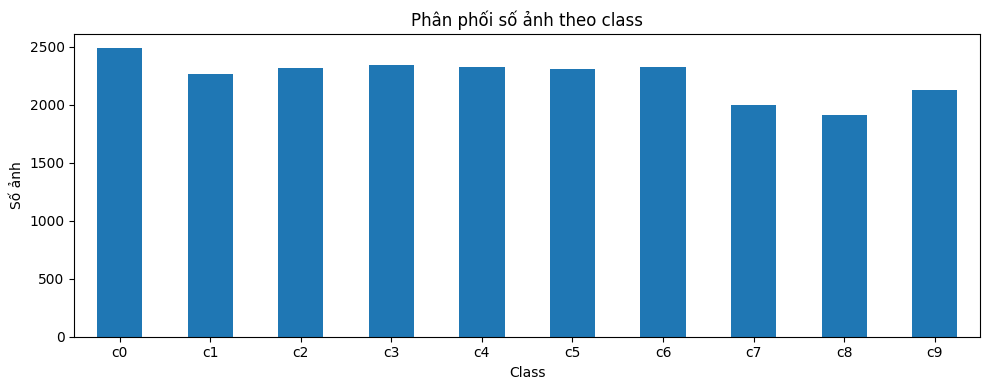

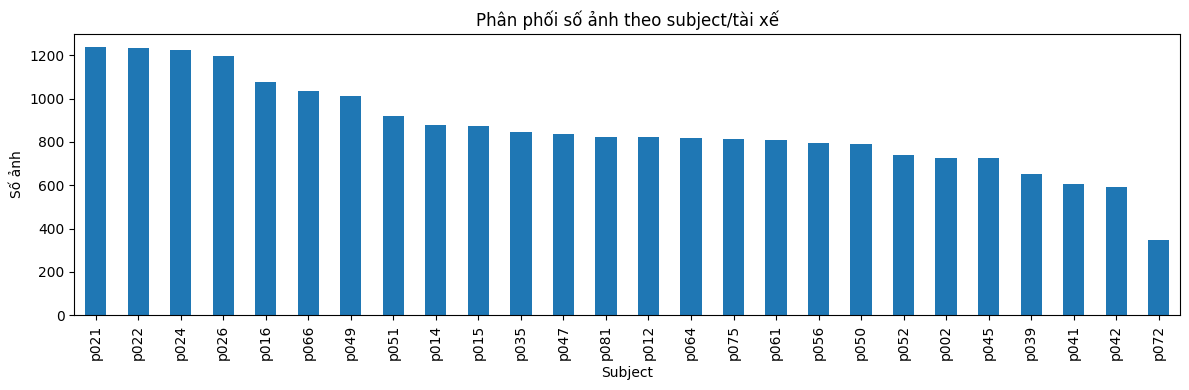

In [6]:
class_counts = df["classname"].value_counts().sort_index()
driver_counts = df["subject"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
class_counts.plot(kind="bar")
plt.title("Phân phối số ảnh theo class")
plt.xlabel("Class")
plt.ylabel("Số ảnh")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
driver_counts.plot(kind="bar")
plt.title("Phân phối số ảnh theo subject/tài xế")
plt.xlabel("Subject")
plt.ylabel("Số ảnh")
plt.tight_layout()
plt.show()


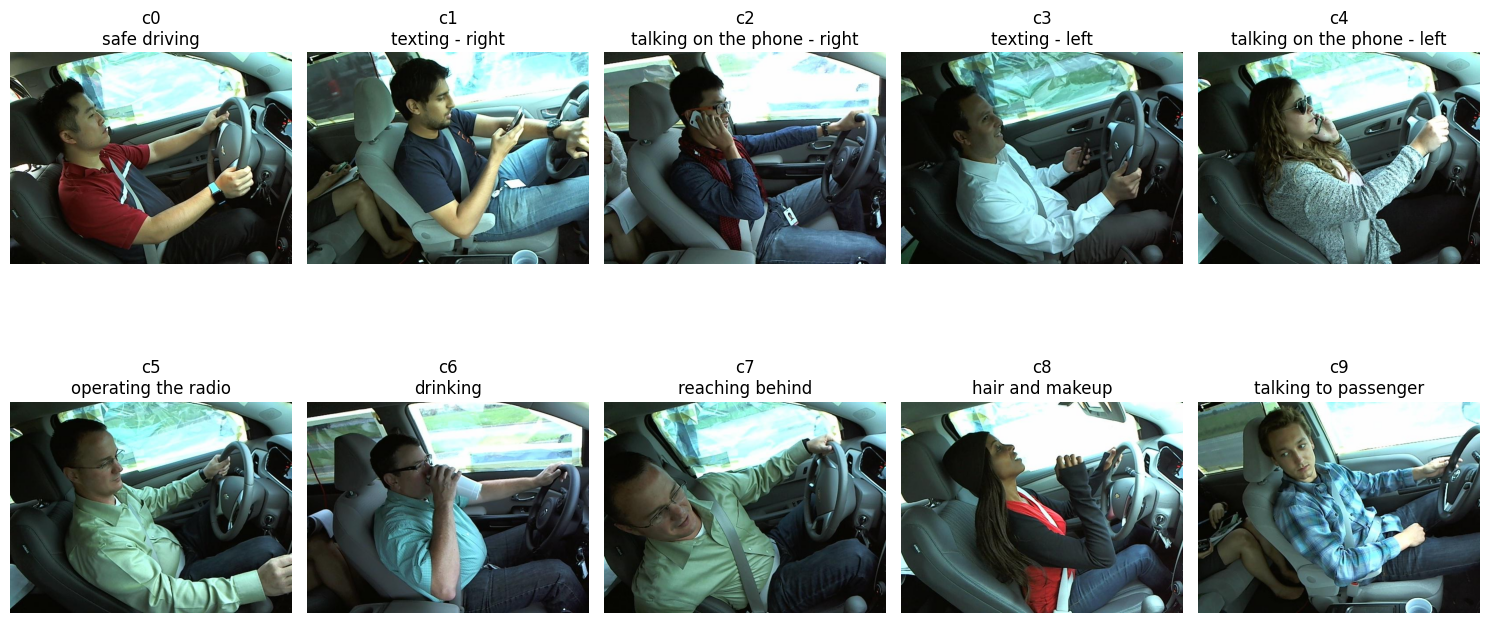

In [7]:
plt.figure(figsize=(15, 8))
for label in range(NUM_CLASSES):
    sample_row = df[df["label"] == label].sample(1, random_state=SEED).iloc[0]
    image = Image.open(sample_row["img_path"]).convert("RGB")
    plt.subplot(2, 5, label + 1)
    plt.imshow(image)
    plt.title(f"{sample_row['classname']}\n{class_description[sample_row['classname']]}")
    plt.axis("off")
plt.tight_layout()
plt.show()


In [8]:
def subject_split(dataframe: pd.DataFrame, val_ratio: float = 0.2, seed=None):

    subjects = sorted(dataframe["subject"].unique())
    train_subjects, val_subjects = train_test_split(
        subjects,
        test_size=val_ratio,
        random_state=seed,
        shuffle=True,
    )
    train_part = dataframe[dataframe["subject"].isin(train_subjects)].reset_index(drop=True)
    val_part = dataframe[dataframe["subject"].isin(val_subjects)].reset_index(drop=True)
    return train_part, val_part, train_subjects, val_subjects

if RANDOMIZE_SUBJECT_SPLIT:
    split_seed = random.SystemRandom().randint(0, 2**32 - 1)
else:
    split_seed = SUBJECT_SPLIT_SEED

train_df, val_df, train_subjects, val_subjects = subject_split(df, val_ratio=VAL_SUBJECT_RATIO, seed=split_seed)

intersection = set(train_df["subject"]).intersection(set(val_df["subject"]))
assert len(intersection) == 0, "Data leakage: subject xuất hiện ở cả train và validation!"

print("Split mode: RANDOM SUBJECT SPLIT" if RANDOMIZE_SUBJECT_SPLIT else "Split mode: FIXED SUBJECT-WISE SPLIT")
print("Split seed used:", split_seed)
print("Train images:", len(train_df))
print("Val images:", len(val_df))
print("Train subjects:", len(train_subjects), sorted(train_subjects))
print("Val subjects:", len(val_subjects), sorted(val_subjects))
print("Subject overlap:", intersection)

if SAVE_SPLIT_INFO:
    split_info = {
        "randomize_subject_split": bool(RANDOMIZE_SUBJECT_SPLIT),
        "split_seed_used": split_seed,
        "val_subject_ratio": VAL_SUBJECT_RATIO,
        "train_subjects": sorted([str(x) for x in train_subjects]),
        "val_subjects": sorted([str(x) for x in val_subjects]),
        "num_train_images": int(len(train_df)),
        "num_val_images": int(len(val_df)),
    }
    split_path = OUTPUT_DIR / "subject_split_info.json"
    with open(split_path, "w", encoding="utf-8") as f:
        json.dump(split_info, f, ensure_ascii=False, indent=2)
    print("Đã lưu thông tin split vào:", split_path)

print("Dùng toàn bộ dữ liệu sau subject-wise split để train/evaluate.")


Split mode: FIXED SUBJECT-WISE SPLIT
Split seed used: 42
Train images: 17446
Val images: 4978
Train subjects: 20 ['p012', 'p014', 'p015', 'p016', 'p021', 'p022', 'p024', 'p039', 'p042', 'p045', 'p047', 'p049', 'p051', 'p052', 'p056', 'p061', 'p064', 'p066', 'p072', 'p081']
Val subjects: 6 ['p002', 'p026', 'p035', 'p041', 'p050', 'p075']
Subject overlap: set()
Đã lưu thông tin split vào: /kaggle/working/statefarm_effb0_project/subject_split_info.json
Dùng toàn bộ dữ liệu sau subject-wise split để train/evaluate.


In [9]:
def safe_cache_filename(row: pd.Series) -> str:

    return f"{row['classname']}_{Path(row['img']).stem}.jpg"

def resize_and_cache_one(src_path: str, dst_path: Path, size: int = CACHE_IMAGE_SIZE) -> bool:

    dst_path.parent.mkdir(parents=True, exist_ok=True)
    if dst_path.exists() and not REBUILD_IMAGE_CACHE:
        return False

    image = None
    if CV2_AVAILABLE:
        bgr = cv2.imread(str(src_path), cv2.IMREAD_COLOR)
        if bgr is not None:
            image = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    if image is None:
        image = np.array(Image.open(src_path).convert("RGB"))

    resized = cv2.resize(image, (size, size), interpolation=cv2.INTER_AREA) if CV2_AVAILABLE else np.array(Image.fromarray(image).resize((size, size)))
    bgr_out = cv2.cvtColor(resized, cv2.COLOR_RGB2BGR) if CV2_AVAILABLE else resized[:, :, ::-1]
    ok = cv2.imwrite(str(dst_path), bgr_out, [int(cv2.IMWRITE_JPEG_QUALITY), int(CACHE_JPEG_QUALITY)]) if CV2_AVAILABLE else False
    if not ok:
        Image.fromarray(resized).save(dst_path, quality=int(CACHE_JPEG_QUALITY))
    return True

def build_resized_cache_for_dataframe(dataframe: pd.DataFrame, split_name: str) -> pd.DataFrame:

    from concurrent.futures import ThreadPoolExecutor, as_completed

    cached_df = dataframe.copy().reset_index(drop=True)
    cached_paths = [None] * len(cached_df)
    cache_split_dir = CACHE_DIR / split_name
    max_workers = int(globals().get("CACHE_NUM_WORKERS", 8))

    def _cache_one(idx: int, row_dict: dict):
        src_path = row_dict["img_path"]
        dst_path = cache_split_dir / row_dict["classname"] / f"{row_dict['classname']}_{Path(row_dict['img']).stem}.jpg"
        created = resize_and_cache_one(src_path, dst_path, size=CACHE_IMAGE_SIZE)
        return idx, str(dst_path), int(created)

    rows = [(idx, cached_df.iloc[idx].to_dict()) for idx in range(len(cached_df))]
    created_count = 0

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(_cache_one, idx, row_dict) for idx, row_dict in rows]
        iterator = tqdm(
            as_completed(futures),
            total=len(futures),
            desc=f"Cache ảnh {split_name} {CACHE_IMAGE_SIZE}px | workers={max_workers}",
            dynamic_ncols=True,
            mininterval=float(globals().get("PROGRESS_MININTERVAL", 5.0)),
            miniters=int(globals().get("PROGRESS_MINITERS", 5)),
            disable=not is_progress_enabled() if "is_progress_enabled" in globals() else False,
        )
        for fut in iterator:
            idx, cached_path, created = fut.result()
            cached_paths[idx] = cached_path
            created_count += created

    cached_df["img_path_original"] = cached_df["img_path"]
    cached_df["img_path"] = cached_paths
    print(f"{split_name}: dùng cache {len(cached_df)} ảnh, tạo mới {created_count} ảnh, workers={max_workers}, thư mục: {cache_split_dir}")
    return cached_df.reset_index(drop=True)

if USE_RESIZED_IMAGE_CACHE:
    print("USE_RESIZED_IMAGE_CACHE=True: bắt đầu chuẩn bị cache ảnh resize để tăng tốc các epoch sau.")
    train_df = build_resized_cache_for_dataframe(train_df, "train")
    val_df = build_resized_cache_for_dataframe(val_df, "val")
else:
    print("USE_RESIZED_IMAGE_CACHE=False: đọc trực tiếp ảnh gốc. Nếu train nhiều epoch/model, nên bật True để nhanh hơn sau bước cache ban đầu.")


USE_RESIZED_IMAGE_CACHE=True: bắt đầu chuẩn bị cache ảnh resize để tăng tốc các epoch sau.


Cache ảnh train 256px | workers=4: 100%|██████████| 17446/17446 [00:51<00:00, 339.61it/s]


train: dùng cache 17446 ảnh, tạo mới 17446 ảnh, workers=4, thư mục: /kaggle/working/statefarm_effb0_project/image_cache_256/train


Cache ảnh val 256px | workers=4: 100%|██████████| 4978/4978 [00:14<00:00, 337.93it/s]

val: dùng cache 4978 ảnh, tạo mới 4978 ảnh, workers=4, thư mục: /kaggle/working/statefarm_effb0_project/image_cache_256/val


,train,val,val_ratio_%
classname,,,
c0,1925,564,22.66
c1,1793,474,20.91
c2,1816,501,21.62
c3,1810,536,22.85
c4,1795,531,22.83
c5,1786,526,22.75
c6,1795,530,22.80
c7,1522,480,23.98
c8,1511,400,20.93


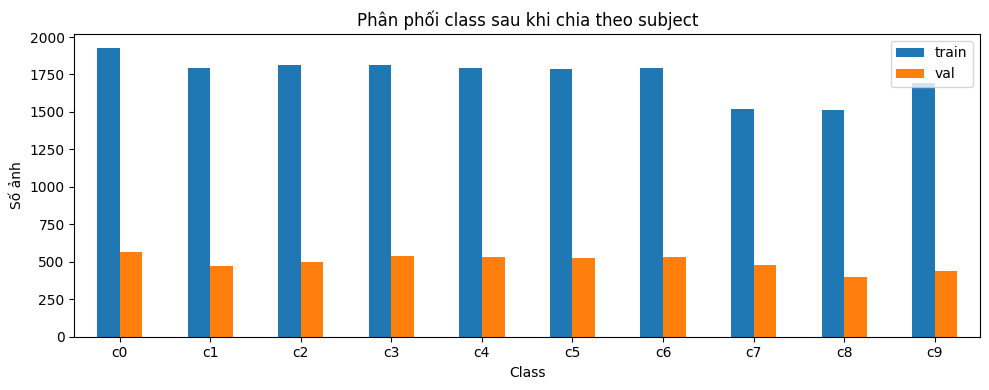

In [10]:
split_distribution = pd.DataFrame({
    "train": train_df["classname"].value_counts().sort_index(),
    "val": val_df["classname"].value_counts().sort_index(),
}).fillna(0).astype(int)

split_distribution["val_ratio_%"] = (split_distribution["val"] / (split_distribution["train"] + split_distribution["val"]) * 100).round(2)
display(split_distribution)

split_distribution[["train", "val"]].plot(kind="bar", figsize=(10, 4))
plt.title("Phân phối class sau khi chia theo subject")
plt.xlabel("Class")
plt.ylabel("Số ảnh")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [11]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

improved_train_tfms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.90, 1.00), ratio=(0.96, 1.04)),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.08, hue=0.015),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.15, scale=(0.02, 0.06), ratio=(0.3, 3.3)),
])

no_aug_train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

strong_train_tfms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.75, 1.00), ratio=(0.85, 1.15)),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.35, contrast=0.35, saturation=0.20, hue=0.04),
    transforms.RandomPerspective(distortion_scale=0.18, p=0.35),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.35, scale=(0.03, 0.18), ratio=(0.3, 3.3)),
])

val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

print("Đã tạo transform train/validation.")


Đã tạo transform train/validation.


In [12]:
class StateFarmDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, transform=None):

        dataframe = dataframe.reset_index(drop=True)
        self.img_paths = dataframe["img_path"].astype(str).tolist()
        self.labels = dataframe["label"].astype(int).tolist()
        self.transform = transform
        self.use_cv2 = bool(globals().get("USE_OPENCV_IMAGE_READER", True)) and CV2_AVAILABLE

    def __len__(self):
        return len(self.img_paths)

    def read_image_rgb(self, path: str):
        if self.use_cv2:
            image_bgr = cv2.imread(path, cv2.IMREAD_COLOR)
            if image_bgr is not None:
                image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
                return Image.fromarray(image_rgb)
        return Image.open(path).convert("RGB")

    def __getitem__(self, idx):
        image = self.read_image_rgb(self.img_paths[idx])
        label = self.labels[idx]
        if self.transform is not None:
            image = self.transform(image)
        return image, label


In [13]:
def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    if CV2_AVAILABLE:

        cv2.setNumThreads(int(globals().get("DATALOADER_WORKER_THREADS", 1)))
    try:
        torch.set_num_threads(int(globals().get("DATALOADER_WORKER_THREADS", 1)))
    except Exception:
        pass

def make_loader_kwargs(num_workers: int):

    kwargs = {
        "num_workers": int(num_workers),
        "pin_memory": bool(globals().get("PIN_MEMORY", True)) and (DEVICE.type == "cuda"),
        "worker_init_fn": seed_worker,
    }
    if num_workers > 0:
        kwargs["persistent_workers"] = bool(globals().get("USE_PERSISTENT_WORKERS", False))
        kwargs["prefetch_factor"] = int(globals().get("PREFETCH_FACTOR", 2))
    return kwargs

def make_loaders(train_transform, batch_size: int = BATCH_SIZE):
    generator = torch.Generator()
    generator.manual_seed(SEED)
    train_dataset = StateFarmDataset(train_df, transform=train_transform)
    val_dataset = StateFarmDataset(val_df, transform=val_tfms)
    loader_kwargs = make_loader_kwargs(NUM_WORKERS)

    train_loader = DataLoader(
        train_dataset,
        batch_size=int(batch_size),
        shuffle=True,
        generator=generator,
        drop_last=False,
        **loader_kwargs,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=int(globals().get("VAL_BATCH_SIZE", batch_size)),
        shuffle=False,
        drop_last=False,
        **loader_kwargs,
    )
    return train_loader, val_loader



In [14]:
def build_efficientnet_b0(num_classes: int = NUM_CLASSES, dropout: float = DROPOUT, pretrained: bool = True):
    weights = models.EfficientNet_B0_Weights.DEFAULT if pretrained else None
    model = models.efficientnet_b0(weights=weights)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout, inplace=True),
        nn.Linear(in_features, num_classes),
    )
    return model

def unwrap_model(model: nn.Module):
    return model

def move_model_to_device(model: nn.Module):
    model = model.to(DEVICE)
    if bool(globals().get("USE_CHANNELS_LAST", False)) and DEVICE.type == "cuda":
        model = model.to(memory_format=torch.channels_last)
    return model

def set_backbone_trainable(model: nn.Module, trainable: bool):
    base_model = unwrap_model(model)
    if hasattr(base_model, "features"):
        for param in base_model.features.parameters():
            param.requires_grad = trainable
    if hasattr(base_model, "classifier"):
        for param in base_model.classifier.parameters():
            param.requires_grad = True
    return model

def count_trainable_params(model: nn.Module):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def save_model_state(model: nn.Module, path: Path):
    torch.save(unwrap_model(model).state_dict(), path)

def load_model_state(model: nn.Module, path: Path, map_location=None):
    state_dict = torch.load(path, map_location=map_location or DEVICE)
    unwrap_model(model).load_state_dict(state_dict)
    return model


In [15]:
def is_progress_enabled():
    return bool(globals().get("SHOW_PROGRESS", True))

def maybe_channels_last(images):
    if bool(globals().get("USE_CHANNELS_LAST", False)) and DEVICE.type == "cuda" and images.ndim == 4:
        return images.contiguous(memory_format=torch.channels_last)
    return images

def train_one_epoch(model, loader, criterion, optimizer, scaler, desc="Train", max_batches=None):

    model.train()
    total_loss = 0.0
    all_preds = []
    all_targets = []
    max_batches = globals().get("MAX_TRAIN_BATCHES", None) if max_batches is None else max_batches

    progress_bar = tqdm(
        loader,
        desc=desc,
        leave=False,
        dynamic_ncols=True,
        mininterval=float(globals().get("PROGRESS_MININTERVAL", 3.0)),
        miniters=int(globals().get("PROGRESS_MINITERS", 3)),
        disable=not is_progress_enabled(),
        total=min(len(loader), max_batches) if max_batches is not None else len(loader),
    )

    for batch_idx, (images, targets) in enumerate(progress_bar, start=1):
        if max_batches is not None and batch_idx > max_batches:
            break
        images = images.to(DEVICE, non_blocking=True)
        images = maybe_channels_last(images)
        targets = targets.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=DEVICE.type, enabled=AMP_ENABLED):
            logits = model(images)
            loss = criterion(logits, targets)

        scaler.scale(loss).backward()

        if bool(globals().get("USE_GRAD_CLIP", False)):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=float(globals().get("MAX_GRAD_NORM", 1.0)))

        scaler.step(optimizer)
        scaler.update()

        batch_size = images.size(0)
        total_loss += loss.item() * batch_size
        preds = logits.argmax(dim=1).detach().cpu().numpy()
        all_preds.extend(preds.tolist())
        all_targets.extend(targets.detach().cpu().numpy().tolist())

        running_loss = total_loss / max(1, len(all_targets))
        progress_bar.set_postfix({
            "loss": f"{running_loss:.4f}",
            "batch": f"{batch_idx}/{max_batches if max_batches is not None else len(loader)}",
            "lr": f"{optimizer.param_groups[0]['lr']:.1e}",
        })

    avg_loss = total_loss / max(1, len(all_targets))
    acc = accuracy_score(all_targets, all_preds) if all_targets else 0.0
    macro_f1 = f1_score(all_targets, all_preds, average="macro", zero_division=0) if all_targets else 0.0
    return avg_loss, acc, macro_f1

@torch.no_grad()
def evaluate(model, loader, criterion, desc="Valid", max_batches=None):
    model.eval()
    total_loss = 0.0
    all_probs = []
    all_preds = []
    all_targets = []
    max_batches = globals().get("MAX_VAL_BATCHES", None) if max_batches is None else max_batches

    progress_bar = tqdm(
        loader,
        desc=desc,
        leave=False,
        dynamic_ncols=True,
        mininterval=float(globals().get("PROGRESS_MININTERVAL", 3.0)),
        miniters=int(globals().get("PROGRESS_MINITERS", 3)),
        disable=not is_progress_enabled(),
        total=min(len(loader), max_batches) if max_batches is not None else len(loader),
    )

    for batch_idx, (images, targets) in enumerate(progress_bar, start=1):
        if max_batches is not None and batch_idx > max_batches:
            break
        images = images.to(DEVICE, non_blocking=True)
        images = maybe_channels_last(images)
        targets = targets.to(DEVICE, non_blocking=True)

        with torch.amp.autocast(device_type=DEVICE.type, enabled=AMP_ENABLED):
            logits = model(images)
            loss = criterion(logits, targets)

        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)

        batch_size = images.size(0)
        total_loss += loss.item() * batch_size
        all_probs.extend(probs.detach().cpu().numpy().tolist())
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_targets.extend(targets.detach().cpu().numpy().tolist())

        running_loss = total_loss / max(1, len(all_targets))
        progress_bar.set_postfix({
            "loss": f"{running_loss:.4f}",
            "batch": f"{batch_idx}/{max_batches if max_batches is not None else len(loader)}",
        })

    avg_loss = total_loss / max(1, len(all_targets))
    acc = accuracy_score(all_targets, all_preds) if all_targets else 0.0
    macro_f1 = f1_score(all_targets, all_preds, average="macro", zero_division=0) if all_targets else 0.0
    return avg_loss, acc, macro_f1, np.array(all_targets), np.array(all_preds), np.array(all_probs)


In [16]:
def get_current_lr(optimizer):
    return float(optimizer.param_groups[0]["lr"])

def make_plateau_scheduler(optimizer):
    if not bool(globals().get("USE_REDUCE_LR", True)):
        return None
    return optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=float(globals().get("LR_REDUCE_FACTOR", 0.5)),
        patience=int(globals().get("LR_REDUCE_PATIENCE", 2)),
        threshold=float(globals().get("LR_REDUCE_THRESHOLD", 1e-4)),
        min_lr=float(globals().get("MIN_LR", 1e-6)),
    )

def diagnose_overfitting(train_loss, train_acc, train_f1, val_loss, val_acc, val_f1):
    warnings = []
    acc_gap = float(train_acc - val_acc)
    f1_gap = float(train_f1 - val_f1)
    loss_ratio = float(val_loss / max(train_loss, 1e-8))

    if acc_gap > float(globals().get("OVERFIT_GAP_WARN", 0.12)):
        warnings.append(f"train_acc cao hơn val_acc {acc_gap:.3f}")
    if f1_gap > float(globals().get("OVERFIT_F1_GAP_WARN", 0.12)):
        warnings.append(f"train_f1 cao hơn val_f1 {f1_gap:.3f}")
    if loss_ratio > float(globals().get("OVERFIT_LOSS_RATIO_WARN", 1.35)):
        warnings.append(f"val_loss/train_loss={loss_ratio:.2f}")

    return warnings, acc_gap, f1_gap, loss_ratio

def run_experiment(exp_name: str, config: dict):
    print("\n" + "=" * 80)
    print(f"Bắt đầu thí nghiệm: {exp_name}")
    print("Mô tả:", config["description"])
    print("=" * 80)

    clean_memory(label=f"trước experiment {exp_name}", verbose=False, kill_workers=True)
    train_loader, val_loader = make_loaders(config["train_transform"], batch_size=BATCH_SIZE)
    criterion = nn.CrossEntropyLoss(label_smoothing=config.get("label_smoothing", LABEL_SMOOTHING))
    exp_dropout = float(config.get("dropout", DROPOUT))
    exp_weight_decay = float(config.get("weight_decay", WEIGHT_DECAY))
    exp_head_lr = float(config.get("head_lr", LR_HEAD))
    exp_fine_lr = float(config.get("fine_lr", LR_FINE))

    if config["model_type"] == "baseline_cnn":
        model = move_model_to_device(SmallCNN(num_classes=NUM_CLASSES))
        optimizer = optim.AdamW(model.parameters(), lr=LR_BASELINE, weight_decay=WEIGHT_DECAY)
        phases = [("baseline_train", EXPERIMENT_EPOCHS[exp_name]["fine"], LR_BASELINE, True)]
    else:
        pretrained_flag = bool(config.get("pretrained", True))
        print(f"Pretrained ImageNet: {pretrained_flag}")
        model = move_model_to_device(build_efficientnet_b0(num_classes=NUM_CLASSES, dropout=exp_dropout, pretrained=pretrained_flag))
        phases = []
        if EXPERIMENT_EPOCHS[exp_name]["head"] > 0:
            phases.append(("head_training", EXPERIMENT_EPOCHS[exp_name]["head"], exp_head_lr, False))
        if EXPERIMENT_EPOCHS[exp_name]["fine"] > 0:
            phases.append(("fine_tuning", EXPERIMENT_EPOCHS[exp_name]["fine"], exp_fine_lr, True))

    history = []
    best_macro_f1 = -1.0
    best_path = OUTPUT_DIR / f"best_{exp_name}.pth"
    if best_path.exists():
        best_path.unlink()
    last_targets = None
    last_preds = None
    last_probs = None

    for phase_name, num_epochs, lr, backbone_trainable in phases:
        if num_epochs <= 0:
            continue

        if config["model_type"] != "baseline_cnn":
            set_backbone_trainable(model, trainable=backbone_trainable)
            optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=exp_weight_decay)

        scheduler = make_plateau_scheduler(optimizer)
        scaler = torch.amp.GradScaler(DEVICE.type, enabled=AMP_ENABLED)

        print(f"\nPhase: {phase_name} | epochs={num_epochs} | lr={lr} | trainable_params={count_trainable_params(model):,}")
        print(f"ReduceLROnPlateau: {scheduler is not None} | grad_clip={bool(globals().get('USE_GRAD_CLIP', False))}")
        print(f"Batch giới hạn: train={MAX_TRAIN_BATCHES}, val={MAX_VAL_BATCHES} | channels_last={USE_CHANNELS_LAST}")

        for epoch in range(1, num_epochs + 1):
            start_time = time.time()
            lr_before = get_current_lr(optimizer)
            train_desc = f"[{exp_name}][{phase_name}][E{epoch:02d}/{num_epochs:02d}] train"
            val_desc = f"[{exp_name}][{phase_name}][E{epoch:02d}/{num_epochs:02d}] valid"

            train_loss, train_acc, train_f1 = train_one_epoch(model, train_loader, criterion, optimizer, scaler, desc=train_desc, max_batches=MAX_TRAIN_BATCHES)
            val_loss, val_acc, val_f1, y_true, y_pred, y_prob = evaluate(model, val_loader, criterion, desc=val_desc, max_batches=MAX_VAL_BATCHES)

            if scheduler is not None:
                scheduler.step(val_f1)
            lr_after = get_current_lr(optimizer)
            elapsed = time.time() - start_time

            overfit_warnings, acc_gap, f1_gap, loss_ratio = diagnose_overfitting(
                train_loss, train_acc, train_f1, val_loss, val_acc, val_f1
            )

            row = {
                "experiment": exp_name,
                "phase": phase_name,
                "epoch_in_phase": epoch,
                "train_loss": train_loss,
                "train_acc": train_acc,
                "train_macro_f1": train_f1,
                "val_loss": val_loss,
                "val_acc": val_acc,
                "val_macro_f1": val_f1,
                "lr_before": lr_before,
                "lr_after": lr_after,
                "acc_gap": acc_gap,
                "f1_gap": f1_gap,
                "loss_ratio": loss_ratio,
                "overfit_warning": " | ".join(overfit_warnings),
                "elapsed_sec": elapsed,
            }
            history.append(row)

            print(f"[{exp_name}][{phase_name}][{epoch:02d}/{num_epochs:02d}] "
                  f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} train_f1={train_f1:.4f} | "
                  f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_f1={val_f1:.4f} | "
                  f"lr={lr_after:.2e} | time={elapsed:.1f}s")

            if lr_after < lr_before:
                print(f"  ↳ ReduceLROnPlateau: LR giảm từ {lr_before:.2e} xuống {lr_after:.2e} vì validation macro F1 bị chững.")

            if overfit_warnings:
                print("  ⚠️ Cảnh báo overfitting:", "; ".join(overfit_warnings))

            if val_f1 > best_macro_f1:
                best_macro_f1 = val_f1
                save_model_state(model, best_path)
                last_targets = y_true
                last_preds = y_pred
                last_probs = y_prob

            if False:
                clean_memory(label=f"sau epoch {exp_name}/{phase_name}/{epoch}", verbose=False, kill_workers=False, deep=False)
            else:
                memory_guard(label=f"epoch {exp_name}/{phase_name}/{epoch}")

        clean_memory(label=f"sau phase {exp_name}/{phase_name}", verbose=False, kill_workers=False, deep=False)

    if best_path.exists():
        load_model_state(model, best_path, map_location=DEVICE)
        val_loss, val_acc, val_f1, last_targets, last_preds, last_probs = evaluate(model, val_loader, criterion, desc=f"[{exp_name}] final valid")
    else:
        val_loss, val_acc, val_f1, last_targets, last_preds, last_probs = evaluate(model, val_loader, criterion, desc=f"[{exp_name}] final valid")

    result = {
        "experiment": exp_name,
        "description": config["description"],
        "best_checkpoint": str(best_path),
        "best_val_loss": float(val_loss),
        "best_val_acc": float(val_acc),
        "best_val_macro_f1": float(val_f1),
        "history": history,
    }

    history_path = OUTPUT_DIR / f"history_{exp_name}.csv"
    pd.DataFrame(history).to_csv(history_path, index=False)

    del train_loader, val_loader
    del model, optimizer, scheduler, scaler, criterion
    clean_memory(
        label=f"sau experiment {exp_name}",
        verbose=False,
        kill_workers=True,
        deep=bool(False),
    )

    return result, last_targets, last_preds, last_probs


In [17]:
EXPERIMENTS = {

    "effb0_pretrained_finetune": {
        "model_type": "efficientnet_b0",
        "pretrained": True,
        "train_transform": improved_train_tfms,
        "label_smoothing": LABEL_SMOOTHING,
        "dropout": DROPOUT,
        "fine_lr": LR_FINE,
        "description": "Có pretrained ImageNet, fine-tune trực tiếp toàn bộ EfficientNet-B0.",
    },

    "effb0_no_pretrain_scratch": {
        "model_type": "efficientnet_b0",
        "pretrained": False,
        "train_transform": improved_train_tfms,
        "label_smoothing": LABEL_SMOOTHING,
        "dropout": DROPOUT,
        "fine_lr": LR_FINE,
        "description": "Không dùng pretrained ImageNet, train EfficientNet-B0 từ đầu để thấy vai trò của transfer learning.",
    },

    "effb0_head_only_frozen": {
        "model_type": "efficientnet_b0",
        "pretrained": True,
        "train_transform": improved_train_tfms,
        "label_smoothing": LABEL_SMOOTHING,
        "dropout": DROPOUT,
        "head_lr": LR_HEAD,
        "description": "Chỉ train classifier head, giữ backbone pretrained cố định để xem đặc trưng ImageNet có đủ dùng không.",
    },

    "effb0_head_warmup": {
        "model_type": "efficientnet_b0",
        "pretrained": True,
        "train_transform": improved_train_tfms,
        "label_smoothing": LABEL_SMOOTHING,
        "dropout": DROPOUT,
        "head_lr": LR_HEAD,
        "fine_lr": LR_FINE,
        "description": "Head warm-up rồi fine-tune toàn bộ, kiểm tra việc làm nóng classifier có giúp ổn định hơn không.",
    },

    "effb0_no_aug": {
        "model_type": "efficientnet_b0",
        "pretrained": True,
        "train_transform": no_aug_train_tfms,
        "label_smoothing": LABEL_SMOOTHING,
        "dropout": DROPOUT,
        "fine_lr": LR_FINE,
        "description": "Có pretrained nhưng không augmentation để quan sát mô hình học thuộc nhanh thế nào.",
    },

    "effb0_strong_aug": {
        "model_type": "efficientnet_b0",
        "pretrained": True,
        "train_transform": strong_train_tfms,
        "label_smoothing": LABEL_SMOOTHING,
        "dropout": DROPOUT,
        "fine_lr": LR_FINE,
        "description": "Có pretrained nhưng augmentation mạnh để kiểm tra biến đổi quá tay có làm giảm hiệu năng không.",
    },

    "effb0_low_lr": {
        "model_type": "efficientnet_b0",
        "pretrained": True,
        "train_transform": improved_train_tfms,
        "label_smoothing": LABEL_SMOOTHING,
        "dropout": DROPOUT,
        "fine_lr": 3e-5,
        "description": "Có pretrained nhưng learning rate thấp hơn, kiểm tra mô hình học chậm ra sao.",
    },

    "effb0_high_lr": {
        "model_type": "efficientnet_b0",
        "pretrained": True,
        "train_transform": improved_train_tfms,
        "label_smoothing": LABEL_SMOOTHING,
        "dropout": DROPOUT,
        "fine_lr": 3e-4,
        "description": "Có pretrained nhưng learning rate cao hơn, kiểm tra nguy cơ dao động hoặc overfit.",
    },

    "effb0_no_dropout": {
        "model_type": "efficientnet_b0",
        "pretrained": True,
        "train_transform": improved_train_tfms,
        "label_smoothing": LABEL_SMOOTHING,
        "dropout": 0.0,
        "fine_lr": LR_FINE,
        "description": "Bỏ dropout để xem classifier có học thuộc mạnh hơn không.",
    },

    "effb0_high_dropout": {
        "model_type": "efficientnet_b0",
        "pretrained": True,
        "train_transform": improved_train_tfms,
        "label_smoothing": LABEL_SMOOTHING,
        "dropout": 0.50,
        "fine_lr": LR_FINE,
        "description": "Tăng dropout để xem regularization mạnh có làm mô hình học chậm hơn không.",
    },

    "effb0_no_label_smoothing": {
        "model_type": "efficientnet_b0",
        "pretrained": True,
        "train_transform": improved_train_tfms,
        "label_smoothing": 0.0,
        "dropout": DROPOUT,
        "fine_lr": LR_FINE,
        "description": "Bỏ label smoothing để xem mô hình tự tin quá mức và overfit thế nào.",
    },
}

SELECTED_EXPERIMENTS = [
    "effb0_pretrained_finetune",
    "effb0_no_pretrain_scratch",
    "effb0_head_only_frozen",
    "effb0_head_warmup",
    "effb0_no_aug",
    "effb0_strong_aug",
    "effb0_low_lr",
    "effb0_high_lr",
    "effb0_no_dropout",
    "effb0_high_dropout",
    "effb0_no_label_smoothing",
]

print("Thí nghiệm sẽ chạy:", SELECTED_EXPERIMENTS)
print("Epoch config:", json.dumps({k: EXPERIMENT_EPOCHS[k] for k in SELECTED_EXPERIMENTS}, indent=2, ensure_ascii=False))



Thí nghiệm sẽ chạy: ['effb0_pretrained_finetune', 'effb0_no_pretrain_scratch', 'effb0_head_only_frozen', 'effb0_head_warmup', 'effb0_no_aug', 'effb0_strong_aug', 'effb0_low_lr', 'effb0_high_lr', 'effb0_no_dropout', 'effb0_high_dropout', 'effb0_no_label_smoothing']
Epoch config: {
  "effb0_pretrained_finetune": {
    "head": 0,
    "fine": 25
  },
  "effb0_no_pretrain_scratch": {
    "head": 0,
    "fine": 25
  },
  "effb0_head_only_frozen": {
    "head": 8,
    "fine": 0
  },
  "effb0_head_warmup": {
    "head": 5,
    "fine": 20
  },
  "effb0_no_aug": {
    "head": 0,
    "fine": 15
  },
  "effb0_strong_aug": {
    "head": 0,
    "fine": 15
  },
  "effb0_low_lr": {
    "head": 0,
    "fine": 15
  },
  "effb0_high_lr": {
    "head": 0,
    "fine": 15
  },
  "effb0_no_dropout": {
    "head": 0,
    "fine": 15
  },
  "effb0_high_dropout": {
    "head": 0,
    "fine": 15
  },
  "effb0_no_label_smoothing": {
    "head": 0,
    "fine": 15
  }
}


In [18]:
all_results = []
prediction_cache = {}

for exp_name in SELECTED_EXPERIMENTS:
    clean_memory(label=f"đầu loop experiment {exp_name}", verbose=False, kill_workers=True)
    result, y_true, y_pred, y_prob = run_experiment(exp_name, EXPERIMENTS[exp_name])
    all_results.append(result)
    prediction_cache[exp_name] = {"y_true": y_true, "y_pred": y_pred, "y_prob": y_prob}
    clean_memory(label=f"cuối loop experiment {exp_name}", verbose=False, kill_workers=True)

summary_df = pd.DataFrame([
    {
        "experiment": r["experiment"],
        "description": r["description"],
        "best_val_loss": r["best_val_loss"],
        "best_val_acc": r["best_val_acc"],
        "best_val_macro_f1": r["best_val_macro_f1"],
        "best_checkpoint": r["best_checkpoint"],
    } for r in all_results
]).sort_values("best_val_macro_f1", ascending=False)

summary_path = OUTPUT_DIR / "experiment_summary_effb0_ablation_playground.csv"
summary_df.to_csv(summary_path, index=False)
display(summary_df)
print("Đã lưu bảng kết quả tại:", summary_path)

if len(summary_df) >= 2:
    print("So sánh nhanh theo Macro F1 validation:")
    display(summary_df[["experiment", "best_val_acc", "best_val_macro_f1", "best_checkpoint"]])



Bắt đầu thí nghiệm: effb0_pretrained_finetune
Mô tả: Có pretrained ImageNet, fine-tune trực tiếp toàn bộ EfficientNet-B0.
Pretrained ImageNet: True
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 204MB/s]



Phase: fine_tuning | epochs=25 | lr=0.0001 | trainable_params=4,020,358
ReduceLROnPlateau: True | grad_clip=True
Batch giới hạn: train=None, val=None | channels_last=True


[effb0_pretrained_finetune][fine_tuning][01/25] train_loss=1.0872 train_acc=0.7605 train_f1=0.7563 | val_loss=0.5611 val_acc=0.8636 val_f1=0.8577 | lr=1.00e-04 | time=220.2s


[effb0_pretrained_finetune][fine_tuning][02/25] train_loss=0.2468 train_acc=0.9856 train_f1=0.9853 | val_loss=0.5683 val_acc=0.8724 val_f1=0.8609 | lr=1.00e-04 | time=75.0s
  ⚠️ Cảnh báo overfitting: train_f1 cao hơn val_f1 0.124; val_loss/train_loss=2.30


...

[effb0_no_label_smoothing][fine_tuning][14/15] train_loss=0.0027 train_acc=0.9994 train_f1=0.9994 | val_loss=0.5745 val_acc=0.8805 val_f1=0.8658 | lr=5.00e-05 | time=74.2s
  ⚠️ Cảnh báo overfitting: train_f1 cao hơn val_f1 0.134; val_loss/train_loss=215.34


[effb0_no_label_smoothing][fine_tuning][15/15] train_loss=0.0023 train_acc=0.9994 train_f1=0.9994 | val_loss=0.5366 val_acc=0.8877 val_f1=0.8716 | lr=2.50e-05 | time=74.4s
  ↳ ReduceLROnPlateau: LR giảm từ 5.00e-05 xuống 2.50e-05 vì validation macro F1 bị chững.
  ⚠️ Cảnh báo overfitting: train_f1 cao hơn val_f1 0.128; val_loss/train_loss=231.38


,experiment,description,best_val_loss,best_val_acc,best_val_macro_f1,best_checkpoint
7,effb0_high_lr,"Có pretrained nhưng learning rate cao hơn, kiể...",0.470091,0.921655,0.912942,/kaggle/working/statefarm_effb0_project/best_e...
5,effb0_strong_aug,Có pretrained nhưng augmentation mạnh để kiểm ...,0.454227,0.916031,0.909310,/kaggle/working/statefarm_effb0_project/best_e...
9,effb0_high_dropout,Tăng dropout để xem regularization mạnh có làm...,0.485456,0.906187,0.898091,/kaggle/working/statefarm_effb0_project/best_e...
0,effb0_pretrained_finetune,"Có pretrained ImageNet, fine-tune trực tiếp to...",0.509967,0.900964,0.893912,/kaggle/working/statefarm_effb0_project/best_e...
10,effb0_no_label_smoothing,Bỏ label smoothing để xem mô hình tự tin quá m...,0.480903,0.891924,0.880690,/kaggle/working/statefarm_effb0_project/best_e...
6,effb0_low_lr,"Có pretrained nhưng learning rate thấp hơn, ki...",0.520253,0.884291,0.877520,/kaggle/working/statefarm_effb0_project/best_e...
4,effb0_no_aug,Có pretrained nhưng không augmentation để quan...,0.567019,0.881679,0.873202,/kaggle/working/statefarm_effb0_project/best_e...
8,effb0_no_dropout,Bỏ dropout để xem classifier có học thuộc mạnh...,0.618932,0.868622,0.866387,/kaggle/working/statefarm_effb0_project/best_e...
3,effb0_head_warmup,"Head warm-up rồi fine-tune toàn bộ, kiểm tra v...",0.568897,0.878063,0.865162,/kaggle/working/statefarm_effb0_project/best_e...
1,effb0_no_pretrain_scratch,"Không dùng pretrained ImageNet, train Efficien...",1.648732,0.547810,0.577289,/kaggle/working/statefarm_effb0_project/best_e...


Đã lưu bảng kết quả tại: /kaggle/working/statefarm_effb0_project/experiment_summary_effb0_ablation_playground.csv
So sánh nhanh theo Macro F1 validation:


,experiment,best_val_acc,best_val_macro_f1,best_checkpoint
7,effb0_high_lr,0.921655,0.912942,/kaggle/working/statefarm_effb0_project/best_e...
5,effb0_strong_aug,0.916031,0.909310,/kaggle/working/statefarm_effb0_project/best_e...
9,effb0_high_dropout,0.906187,0.898091,/kaggle/working/statefarm_effb0_project/best_e...
0,effb0_pretrained_finetune,0.900964,0.893912,/kaggle/working/statefarm_effb0_project/best_e...
10,effb0_no_label_smoothing,0.891924,0.880690,/kaggle/working/statefarm_effb0_project/best_e...
6,effb0_low_lr,0.884291,0.877520,/kaggle/working/statefarm_effb0_project/best_e...
4,effb0_no_aug,0.881679,0.873202,/kaggle/working/statefarm_effb0_project/best_e...
8,effb0_no_dropout,0.868622,0.866387,/kaggle/working/statefarm_effb0_project/best_e...
3,effb0_head_warmup,0.878063,0.865162,/kaggle/working/statefarm_effb0_project/best_e...
1,effb0_no_pretrain_scratch,0.547810,0.577289,/kaggle/working/statefarm_effb0_project/best_e...


In [19]:
EXPORT_DIR = OUTPUT_DIR / "effb0_export"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

for pattern in ["*.pth", "*.pt", "*.csv", "*.png", "*.json"]:
    for f in OUTPUT_DIR.rglob(pattern):
        if f.is_file():
            try:
                shutil.copy2(f, EXPORT_DIR / f.name)
            except Exception as e:
                print("Không copy được", f, repr(e))

zip_path = shutil.make_archive(str(OUTPUT_DIR / "effb0_ablation_export"), "zip", EXPORT_DIR)
print("Đã export model và kết quả:", zip_path)

try:
    from IPython.display import FileLink
    display(FileLink(zip_path))
except Exception:
    pass


Không copy được /kaggle/working/statefarm_effb0_project/effb0_export/best_effb0_no_aug.pth SameFileError("PosixPath('/kaggle/working/statefarm_effb0_project/effb0_export/best_effb0_no_aug.pth') and PosixPath('/kaggle/working/statefarm_effb0_project/effb0_export/best_effb0_no_aug.pth') are the same file")
Không copy được /kaggle/working/statefarm_effb0_project/effb0_export/best_effb0_strong_aug.pth SameFileError("PosixPath('/kaggle/working/statefarm_effb0_project/effb0_export/best_effb0_strong_aug.pth') and PosixPath('/kaggle/working/statefarm_effb0_project/effb0_export/best_effb0_strong_aug.pth') are the same file")
Không copy được /kaggle/working/statefarm_effb0_project/effb0_export/best_effb0_low_lr.pth SameFileError("PosixPath('/kaggle/working/statefarm_effb0_project/effb0_export/best_effb0_low_lr.pth') and PosixPath('/kaggle/working/statefarm_effb0_project/effb0_export/best_effb0_low_lr.pth') are the same file")
Không copy được /kaggle/working/statefarm_effb0_project/effb0_export/b

/kaggle/working/statefarm_effb0_project/effb0_ablation_export.zip

In [20]:
PLOT_DIR = OUTPUT_DIR / "plots"
PER_EXP_DIR = PLOT_DIR / "per_experiment"
PLOT_DIR.mkdir(parents=True, exist_ok=True)
PER_EXP_DIR.mkdir(parents=True, exist_ok=True)

plot_catalog = []
per_class_metric_tables = []
top_confusion_tables = []

def _save_line_plot(x, series_dict, title, xlabel, ylabel, save_path):
    """Vẽ 1 biểu đồ đường và lưu ra file PNG."""
    plt.figure(figsize=(8, 5))
    for label, values in series_dict.items():
        plt.plot(x, values, marker="o", label=label)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.close()
    return save_path

def _save_bar_plot(labels, values, title, xlabel, ylabel, save_path, rotation=30):
    """Vẽ 1 biểu đồ cột và lưu ra file PNG."""
    plt.figure(figsize=(9, 5))
    plt.bar(labels, values)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=rotation, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.close()
    return save_path

def _save_confusion_matrix_plot(cm, labels, title, save_path, normalize=False):
    """Vẽ confusion matrix an toàn bằng matplotlib thuần.

    Không dùng seaborn để tránh lỗi format `d`/float giữa count matrix và normalized matrix.
    - normalize=False: ma trận count, hiển thị số nguyên.
    - normalize=True: ma trận chuẩn hóa theo hàng, hiển thị 2 chữ số thập phân.
    """
    cm = np.asarray(cm)

    if normalize:
        cm_float = cm.astype(float)
        row_sum = cm_float.sum(axis=1, keepdims=True)
        matrix = np.divide(
            cm_float,
            row_sum,
            out=np.zeros_like(cm_float, dtype=float),
            where=row_sum != 0,
        )
        text_func = lambda v: f"{float(v):.2f}"
    else:
        matrix = cm.astype(np.int64)
        text_func = lambda v: f"{int(v)}"

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(matrix, cmap="Blues")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)

    max_val = float(np.nanmax(matrix)) if matrix.size else 0.0
    threshold = max_val / 2.0 if max_val > 0 else 0.0
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            value = matrix[i, j]
            color = "white" if float(value) > threshold else "black"
            ax.text(j, i, text_func(value), ha="center", va="center", color=color, fontsize=8)

    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    fig.tight_layout()
    fig.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.close(fig)
    return save_path

def _classification_report_to_df(y_true, y_pred, target_names):
    """Chuyển classification report sang DataFrame để lưu CSV và vẽ per-class metrics."""
    report_dict = classification_report(
        y_true,
        y_pred,
        labels=list(range(NUM_CLASSES)),
        target_names=target_names,
        output_dict=True,
        zero_division=0,
    )
    report_df = pd.DataFrame(report_dict).T.reset_index().rename(columns={"index": "class"})
    return report_df

def _extract_top_confusions(cm, top_k=10):
    """Lấy các cặp nhầm nhiều nhất từ confusion matrix."""
    rows = []
    for true_idx in range(NUM_CLASSES):
        for pred_idx in range(NUM_CLASSES):
            if true_idx == pred_idx:
                continue
            count = int(cm[true_idx, pred_idx])
            if count > 0:
                rows.append({
                    "true_class": idx_to_class[true_idx],
                    "pred_class": idx_to_class[pred_idx],
                    "count": count,
                    "true_description": class_description[idx_to_class[true_idx]],
                    "pred_description": class_description[idx_to_class[pred_idx]],
                })
    return pd.DataFrame(rows).sort_values("count", ascending=False).head(top_k) if rows else pd.DataFrame(rows)

if "all_results" not in globals() or len(all_results) == 0:
    print("Chưa có kết quả thí nghiệm. Hãy chạy cell train trước.")
else:
    target_names = [f"{c}: {class_description[c]}" for c in class_names]

    print("=" * 90)
    print("XUẤT BÁO CÁO RIÊNG CHO TỪNG PHƯƠNG ÁN EFFICIENTNET-B0")
    print("=" * 90)

    for result in all_results:
        exp_name = result["experiment"]
        exp_dir = PER_EXP_DIR / exp_name
        exp_dir.mkdir(parents=True, exist_ok=True)

        hist = pd.DataFrame(result.get("history", []))
        if len(hist) == 0:
            print(f"[{exp_name}] Không có history, bỏ qua plot.")
            continue

        hist["global_epoch"] = np.arange(1, len(hist) + 1)
        history_path = exp_dir / f"{exp_name}_history.csv"
        hist.to_csv(history_path, index=False)
        plot_catalog.append({"experiment": exp_name, "type": "history_csv", "path": str(history_path)})

        print(f"\n[{exp_name}]")
        print("Mô tả:", result.get("description", ""))
        print(f"Best Val Acc={result['best_val_acc']:.4f} | Best Macro F1={result['best_val_macro_f1']:.4f}")

        acc_path = exp_dir / f"{exp_name}_01_accuracy_curve.png"
        _save_line_plot(
            hist["global_epoch"],
            {"train_acc": hist["train_acc"], "val_acc": hist["val_acc"]},
            f"Accuracy Curve - {exp_name}",
            "Epoch",
            "Accuracy",
            acc_path,
        )
        plot_catalog.append({"experiment": exp_name, "type": "accuracy_curve", "path": str(acc_path)})

        loss_path = exp_dir / f"{exp_name}_02_loss_curve.png"
        _save_line_plot(
            hist["global_epoch"],
            {"train_loss": hist["train_loss"], "val_loss": hist["val_loss"]},
            f"Loss Curve - {exp_name}",
            "Epoch",
            "Loss",
            loss_path,
        )
        plot_catalog.append({"experiment": exp_name, "type": "loss_curve", "path": str(loss_path)})

        f1_path = exp_dir / f"{exp_name}_03_macro_f1_curve.png"
        _save_line_plot(
            hist["global_epoch"],
            {"train_macro_f1": hist["train_macro_f1"], "val_macro_f1": hist["val_macro_f1"]},
            f"Macro F1 Curve - {exp_name}",
            "Epoch",
            "Macro F1",
            f1_path,
        )
        plot_catalog.append({"experiment": exp_name, "type": "macro_f1_curve", "path": str(f1_path)})

        lr_path = exp_dir / f"{exp_name}_04_learning_rate_curve.png"
        lr_col = "lr_after" if "lr_after" in hist.columns else "lr_before"
        _save_line_plot(
            hist["global_epoch"],
            {"learning_rate": hist[lr_col]},
            f"Learning Rate - {exp_name}",
            "Epoch",
            "LR",
            lr_path,
        )
        plot_catalog.append({"experiment": exp_name, "type": "learning_rate_curve", "path": str(lr_path)})

        gap_path = exp_dir / f"{exp_name}_05_train_val_gap_curve.png"
        gap_series = {}
        if "acc_gap" in hist.columns:
            gap_series["acc_gap"] = hist["acc_gap"]
        if "f1_gap" in hist.columns:
            gap_series["f1_gap"] = hist["f1_gap"]
        if gap_series:
            _save_line_plot(
                hist["global_epoch"],
                gap_series,
                f"Train-Val Gap - {exp_name}",
                "Epoch",
                "Gap",
                gap_path,
            )
            plot_catalog.append({"experiment": exp_name, "type": "train_val_gap_curve", "path": str(gap_path)})

        pred_pack = prediction_cache.get(exp_name)
        if pred_pack is not None:
            y_true_exp = pred_pack["y_true"]
            y_pred_exp = pred_pack["y_pred"]

            report_df = _classification_report_to_df(y_true_exp, y_pred_exp, target_names)
            report_csv_path = exp_dir / f"{exp_name}_classification_report.csv"
            report_txt_path = exp_dir / f"{exp_name}_classification_report.txt"
            report_df.to_csv(report_csv_path, index=False)
            with open(report_txt_path, "w", encoding="utf-8") as f:
                f.write(classification_report(y_true_exp, y_pred_exp, labels=list(range(NUM_CLASSES)), target_names=target_names, zero_division=0))
            plot_catalog.append({"experiment": exp_name, "type": "classification_report_csv", "path": str(report_csv_path)})
            plot_catalog.append({"experiment": exp_name, "type": "classification_report_txt", "path": str(report_txt_path)})

            class_rows = report_df[report_df["class"].astype(str).str.startswith("c")].copy()
            class_rows["short_class"] = class_rows["class"].astype(str).str.split(":").str[0]
            class_rows["experiment"] = exp_name
            per_class_metric_tables.append(class_rows)

            per_class_f1_path = exp_dir / f"{exp_name}_06_per_class_f1.png"
            _save_bar_plot(
                class_rows["short_class"],
                class_rows["f1-score"],
                f"Per-class F1 - {exp_name}",
                "Class",
                "F1-score",
                per_class_f1_path,
                rotation=0,
            )
            plot_catalog.append({"experiment": exp_name, "type": "per_class_f1_bar", "path": str(per_class_f1_path)})

            cm = confusion_matrix(y_true_exp, y_pred_exp, labels=list(range(NUM_CLASSES)))
            cm_raw_path = exp_dir / f"{exp_name}_07_confusion_matrix_count.png"
            _save_confusion_matrix_plot(
                cm,
                class_names,
                f"Confusion Matrix Count - {exp_name}",
                cm_raw_path,
                normalize=False,
            )
            plot_catalog.append({"experiment": exp_name, "type": "confusion_matrix_count", "path": str(cm_raw_path)})

            cm_norm_path = exp_dir / f"{exp_name}_08_confusion_matrix_normalized.png"
            _save_confusion_matrix_plot(
                cm,
                class_names,
                f"Confusion Matrix Normalized - {exp_name}",
                cm_norm_path,
                normalize=True,
            )
            plot_catalog.append({"experiment": exp_name, "type": "confusion_matrix_normalized", "path": str(cm_norm_path)})

            top_confusions = _extract_top_confusions(cm, top_k=10)
            if len(top_confusions) > 0:
                top_confusions["experiment"] = exp_name
                top_confusion_tables.append(top_confusions)
                top_conf_path = exp_dir / f"{exp_name}_top_confusions.csv"
                top_confusions.to_csv(top_conf_path, index=False)
                plot_catalog.append({"experiment": exp_name, "type": "top_confusions_csv", "path": str(top_conf_path)})

                top_conf_bar_path = exp_dir / f"{exp_name}_09_top_confusions_bar.png"
                top_labels = [f"{r.true_class}->{r.pred_class}" for r in top_confusions.itertuples()]
                _save_bar_plot(
                    top_labels,
                    top_confusions["count"],
                    f"Top Confusions - {exp_name}",
                    "True → Predicted",
                    "Count",
                    top_conf_bar_path,
                    rotation=45,
                )
                plot_catalog.append({"experiment": exp_name, "type": "top_confusions_bar", "path": str(top_conf_bar_path)})

        print("Đã xuất hình/report vào:", exp_dir)

    plot_catalog_df = pd.DataFrame(plot_catalog)
    plot_catalog_path = OUTPUT_DIR / "plot_catalog_per_experiment.csv"
    plot_catalog_df.to_csv(plot_catalog_path, index=False)

    if per_class_metric_tables:
        per_class_metrics_all = pd.concat(per_class_metric_tables, ignore_index=True)
        per_class_metrics_path = OUTPUT_DIR / "per_class_metrics_all_experiments.csv"
        per_class_metrics_all.to_csv(per_class_metrics_path, index=False)
        print("Đã lưu per-class metrics tổng:", per_class_metrics_path)

    if top_confusion_tables:
        top_confusions_all = pd.concat(top_confusion_tables, ignore_index=True)
        top_confusions_path = OUTPUT_DIR / "top_confusions_all_experiments.csv"
        top_confusions_all.to_csv(top_confusions_path, index=False)
        print("Đã lưu top confusions tổng:", top_confusions_path)

    print("\nCatalog toàn bộ hình/report đã xuất:")
    display(plot_catalog_df)
    print("Đã lưu catalog:", plot_catalog_path)

if bool(False):
    clean_memory(label="sau xuất biểu đồ từng thí nghiệm", verbose=False, kill_workers=False, deep=True)


XUẤT BÁO CÁO RIÊNG CHO TỪNG PHƯƠNG ÁN EFFICIENTNET-B0

[effb0_pretrained_finetune]
Mô tả: Có pretrained ImageNet, fine-tune trực tiếp toàn bộ EfficientNet-B0.
Best Val Acc=0.9010 | Best Macro F1=0.8939
Đã xuất hình/report vào: /kaggle/working/statefarm_effb0_project/plots/per_experiment/effb0_pretrained_finetune

[effb0_no_pretrain_scratch]
Mô tả: Không dùng pretrained ImageNet, train EfficientNet-B0 từ đầu để thấy vai trò của transfer learning.
Best Val Acc=0.5478 | Best Macro F1=0.5773
Đã xuất hình/report vào: /kaggle/working/statefarm_effb0_project/plots/per_experiment/effb0_no_pretrain_scratch

[effb0_head_only_frozen]
Mô tả: Chỉ train classifier head, giữ backbone pretrained cố định để xem đặc trưng ImageNet có đủ dùng không.
Best Val Acc=0.5426 | Best Macro F1=0.5326
Đã xuất hình/report vào: /kaggle/working/statefarm_effb0_project/plots/per_experiment/effb0_head_only_frozen

[effb0_head_warmup]
Mô tả: Head warm-up rồi fine-tune toàn bộ, kiểm tra việc làm nóng classifier có giúp ổ

,experiment,type,path
0,effb0_pretrained_finetune,history_csv,/kaggle/working/statefarm_effb0_project/plots/...
1,effb0_pretrained_finetune,accuracy_curve,/kaggle/working/statefarm_effb0_project/plots/...
2,effb0_pretrained_finetune,loss_curve,/kaggle/working/statefarm_effb0_project/plots/...
3,effb0_pretrained_finetune,macro_f1_curve,/kaggle/working/statefarm_effb0_project/plots/...
4,effb0_pretrained_finetune,learning_rate_curve,/kaggle/working/statefarm_effb0_project/plots/...
...,...,...,...
138,effb0_no_label_smoothing,per_class_f1_bar,/kaggle/working/statefarm_effb0_project/plots/...
139,effb0_no_label_smoothing,confusion_matrix_count,/kaggle/working/statefarm_effb0_project/plots/...
140,effb0_no_label_smoothing,confusion_matrix_normalized,/kaggle/working/statefarm_effb0_project/plots/...
141,effb0_no_label_smoothing,top_confusions_csv,/kaggle/working/statefarm_effb0_project/plots/...


Đã lưu catalog: /kaggle/working/statefarm_effb0_project/plot_catalog_per_experiment.csv


,experiment,best_val_acc,best_val_macro_f1,best_phase,best_epoch_from_history,acc_gap_at_best_f1,f1_gap_at_best_f1,total_train_time_min,best_checkpoint
0,effb0_high_lr,0.921655,0.912942,fine_tuning,13,0.078115,0.086833,18.297501,/kaggle/working/statefarm_effb0_project/best_e...
1,effb0_strong_aug,0.916031,0.909310,fine_tuning,4,0.065226,0.071880,20.485427,/kaggle/working/statefarm_effb0_project/best_e...
2,effb0_high_dropout,0.906187,0.898091,fine_tuning,14,0.093526,0.101623,18.397669,/kaggle/working/statefarm_effb0_project/best_e...
3,effb0_pretrained_finetune,0.900964,0.893912,fine_tuning,18,0.098635,0.105671,33.086080,/kaggle/working/statefarm_effb0_project/best_e...
4,effb0_no_label_smoothing,0.891924,0.880690,fine_tuning,9,0.107158,0.118394,18.404676,/kaggle/working/statefarm_effb0_project/best_e...
5,effb0_low_lr,0.884291,0.877520,fine_tuning,13,0.113072,0.119807,18.306863,/kaggle/working/statefarm_effb0_project/best_e...
6,effb0_no_aug,0.881679,0.873202,fine_tuning,13,0.118091,0.126567,11.390440,/kaggle/working/statefarm_effb0_project/best_e...
7,effb0_no_dropout,0.868622,0.866387,fine_tuning,1,-0.067349,-0.070709,18.319328,/kaggle/working/statefarm_effb0_project/best_e...
8,effb0_head_warmup,0.878063,0.865162,fine_tuning,19,0.121593,0.134472,30.241684,/kaggle/working/statefarm_effb0_project/best_e...
9,effb0_no_pretrain_scratch,0.547810,0.577289,fine_tuning,10,0.421065,0.390978,30.289000,/kaggle/working/statefarm_effb0_project/best_e...


Đã lưu bảng so sánh đầy đủ: /kaggle/working/statefarm_effb0_project/comparison_summary_full.csv


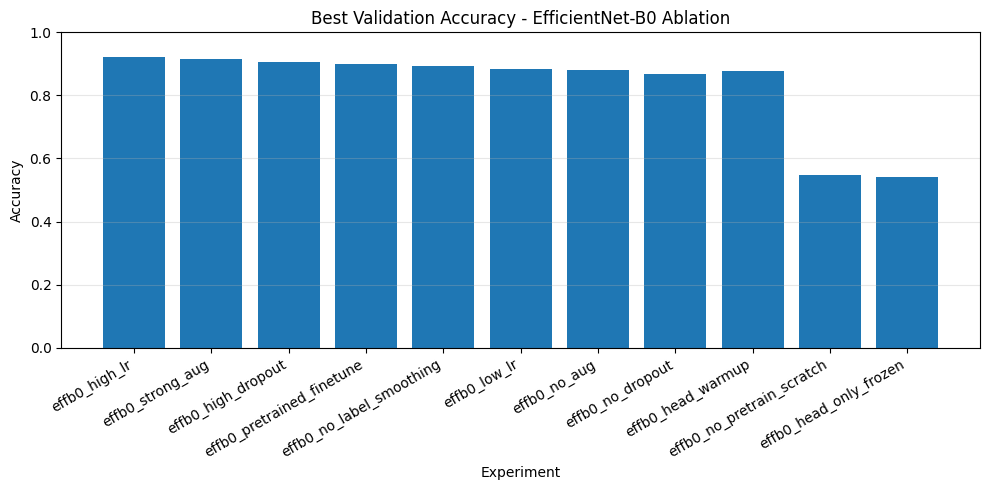

Đã lưu: /kaggle/working/statefarm_effb0_project/plots/comparison/comparison_01_best_val_accuracy.png


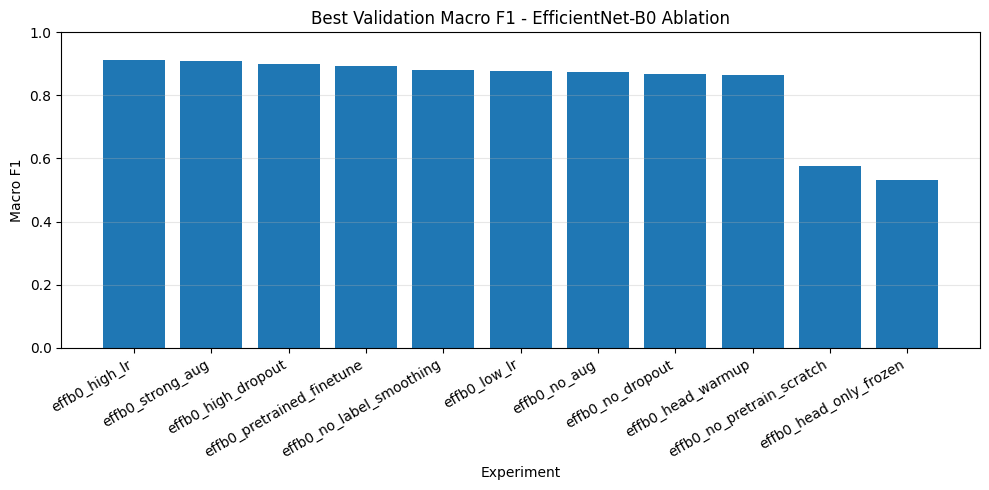

Đã lưu: /kaggle/working/statefarm_effb0_project/plots/comparison/comparison_02_best_macro_f1.png


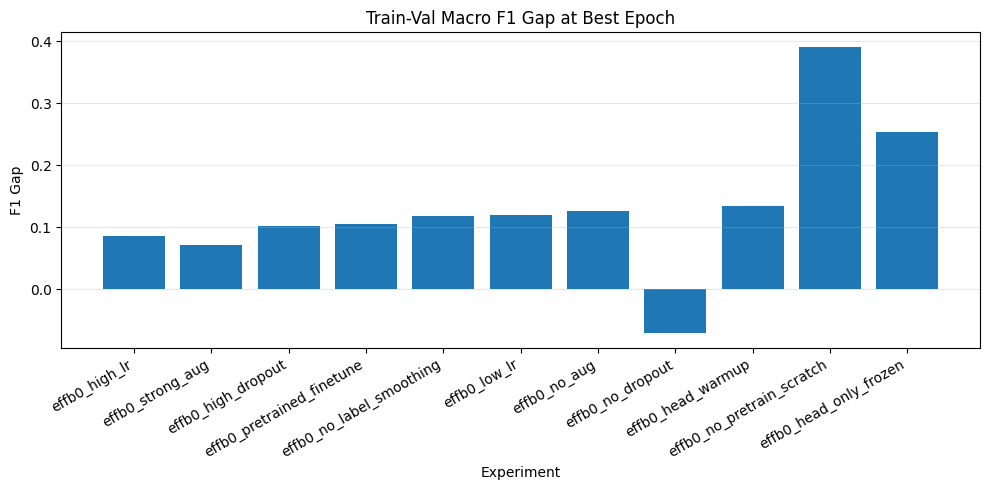

Đã lưu: /kaggle/working/statefarm_effb0_project/plots/comparison/comparison_03_f1_gap_at_best_epoch.png


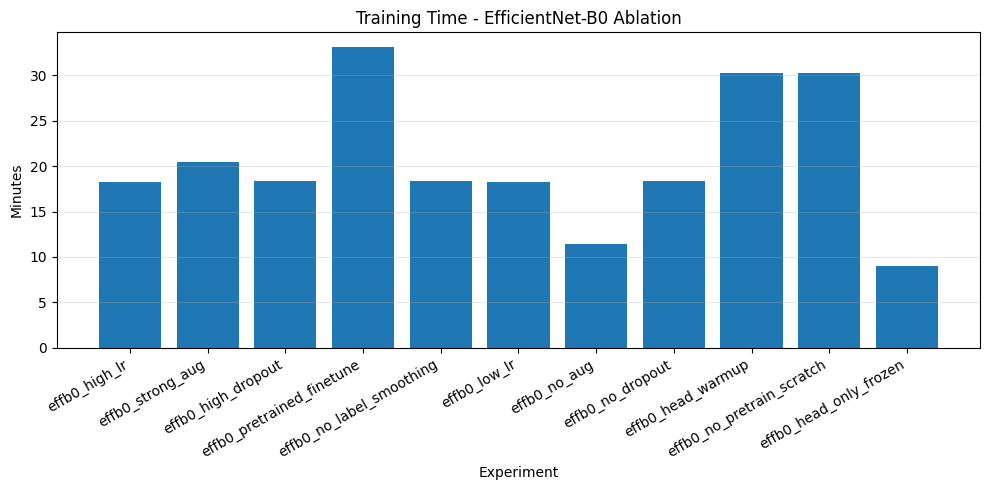

Đã lưu: /kaggle/working/statefarm_effb0_project/plots/comparison/comparison_04_training_time_minutes.png

Mô hình tốt nhất theo validation Macro F1: effb0_high_lr
Checkpoint: /kaggle/working/statefarm_effb0_project/best_effb0_high_lr.pth


In [21]:
COMPARE_DIR = OUTPUT_DIR / "plots" / "comparison"
COMPARE_DIR.mkdir(parents=True, exist_ok=True)

if "summary_df" not in globals() or len(summary_df) == 0:
    print("Chưa có summary_df. Hãy chạy thí nghiệm trước.")
else:
    compare_df = summary_df.copy().sort_values("best_val_macro_f1", ascending=False)

    rows = []
    for result in all_results:
        hist = pd.DataFrame(result.get("history", []))
        if len(hist) == 0:
            continue
        best_idx = hist["val_macro_f1"].idxmax()
        best_row = hist.loc[best_idx].to_dict()
        rows.append({
            "experiment": result["experiment"],
            "best_epoch_from_history": int(best_row.get("epoch_in_phase", 0)),
            "best_phase": best_row.get("phase", ""),
            "best_train_acc_at_best_f1": best_row.get("train_acc", np.nan),
            "best_val_acc_from_history": best_row.get("val_acc", np.nan),
            "best_train_f1_at_best_f1": best_row.get("train_macro_f1", np.nan),
            "best_val_f1_from_history": best_row.get("val_macro_f1", np.nan),
            "acc_gap_at_best_f1": best_row.get("acc_gap", np.nan),
            "f1_gap_at_best_f1": best_row.get("f1_gap", np.nan),
            "loss_ratio_at_best_f1": best_row.get("loss_ratio", np.nan),
            "total_train_time_min": hist.get("elapsed_sec", pd.Series(dtype=float)).sum() / 60.0,
            "last_lr": best_row.get("lr_after", np.nan),
        })

    diagnostics_df = pd.DataFrame(rows)
    compare_full_df = compare_df.merge(diagnostics_df, on="experiment", how="left")
    compare_full_path = OUTPUT_DIR / "comparison_summary_full.csv"
    compare_full_df.to_csv(compare_full_path, index=False)

    display_cols = [
        "experiment", "best_val_acc", "best_val_macro_f1",
        "best_phase", "best_epoch_from_history",
        "acc_gap_at_best_f1", "f1_gap_at_best_f1",
        "total_train_time_min", "best_checkpoint",
    ]
    display(compare_full_df[[c for c in display_cols if c in compare_full_df.columns]])
    print("Đã lưu bảng so sánh đầy đủ:", compare_full_path)

    x_labels = compare_full_df["experiment"].tolist()

    acc_cmp_path = COMPARE_DIR / "comparison_01_best_val_accuracy.png"
    plt.figure(figsize=(10, 5))
    plt.bar(x_labels, compare_full_df["best_val_acc"])
    plt.title("Best Validation Accuracy - EfficientNet-B0 Ablation")
    plt.xlabel("Experiment")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1)
    plt.xticks(rotation=30, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(acc_cmp_path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Đã lưu:", acc_cmp_path)

    f1_cmp_path = COMPARE_DIR / "comparison_02_best_macro_f1.png"
    plt.figure(figsize=(10, 5))
    plt.bar(x_labels, compare_full_df["best_val_macro_f1"])
    plt.title("Best Validation Macro F1 - EfficientNet-B0 Ablation")
    plt.xlabel("Experiment")
    plt.ylabel("Macro F1")
    plt.ylim(0, 1)
    plt.xticks(rotation=30, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(f1_cmp_path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Đã lưu:", f1_cmp_path)

    if "f1_gap_at_best_f1" in compare_full_df.columns:
        gap_cmp_path = COMPARE_DIR / "comparison_03_f1_gap_at_best_epoch.png"
        plt.figure(figsize=(10, 5))
        plt.bar(x_labels, compare_full_df["f1_gap_at_best_f1"])
        plt.title("Train-Val Macro F1 Gap at Best Epoch")
        plt.xlabel("Experiment")
        plt.ylabel("F1 Gap")
        plt.xticks(rotation=30, ha="right")
        plt.grid(axis="y", alpha=0.3)
        plt.tight_layout()
        plt.savefig(gap_cmp_path, dpi=180, bbox_inches="tight")
        plt.show()
        print("Đã lưu:", gap_cmp_path)

    if "total_train_time_min" in compare_full_df.columns:
        time_cmp_path = COMPARE_DIR / "comparison_04_training_time_minutes.png"
        plt.figure(figsize=(10, 5))
        plt.bar(x_labels, compare_full_df["total_train_time_min"])
        plt.title("Training Time - EfficientNet-B0 Ablation")
        plt.xlabel("Experiment")
        plt.ylabel("Minutes")
        plt.xticks(rotation=30, ha="right")
        plt.grid(axis="y", alpha=0.3)
        plt.tight_layout()
        plt.savefig(time_cmp_path, dpi=180, bbox_inches="tight")
        plt.show()
        print("Đã lưu:", time_cmp_path)

    best_experiment_name = compare_full_df.iloc[0]["experiment"]
    print("\nMô hình tốt nhất theo validation Macro F1:", best_experiment_name)
    print("Checkpoint:", compare_full_df.iloc[0]["best_checkpoint"])

if bool(False):
    clean_memory(label="sau xuất biểu đồ so sánh", verbose=False, kill_workers=False, deep=True)


In [22]:
COMPLETE_DIR = OUTPUT_DIR / "complete_outputs"
PER_EXP_DIR = COMPLETE_DIR / "per_experiment"
COMPARE_DIR = COMPLETE_DIR / "comparison"

COMPLETE_DIR.mkdir(parents=True, exist_ok=True)
PER_EXP_DIR.mkdir(parents=True, exist_ok=True)
COMPARE_DIR.mkdir(parents=True, exist_ok=True)

manifest_rows = []

def record_file(path, group, file_type, note=""):
    path = Path(path)
    if path.exists():
        manifest_rows.append({
            "group": group,
            "file_type": file_type,
            "path": str(path),
            "note": note,
        })

def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def safe_divide(a, b):
    return np.divide(
        a,
        np.maximum(b, 1e-8),
        out=np.zeros_like(a, dtype=float),
        where=np.maximum(b, 1e-8) != 0,
    )

def plot_curve(df, x_col, y_cols, labels, title, ylabel, save_path, ylim=None):
    plt.figure(figsize=(9, 5))

    plotted = False
    for col, label in zip(y_cols, labels):
        if col is not None and col in df.columns:
            plt.plot(df[x_col], df[col], marker="o", label=label)
            plotted = True

    if not plotted:
        plt.text(0.5, 0.5, "No valid columns found", ha="center", va="center")

    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)

    if ylim is not None:
        plt.ylim(*ylim)

    plt.grid(True, alpha=0.3)

    if plotted:
        plt.legend()

    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.close()

    record_file(save_path, "per_experiment", "plot", title)

def plot_bar(labels, values, title, ylabel, save_path, rotation=30, ylim=None):
    plt.figure(figsize=(10, 5))
    plt.bar(labels, values)
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel(ylabel)

    if ylim is not None:
        plt.ylim(*ylim)

    plt.xticks(rotation=rotation, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.close()

    record_file(save_path, "per_experiment", "plot", title)

def plot_confusion_matrix_safe(cm, labels, title, save_path, normalize=False):
    cm = np.asarray(cm)

    if normalize:
        cm_float = cm.astype(float)
        row_sum = cm_float.sum(axis=1, keepdims=True)
        matrix = np.divide(
            cm_float,
            row_sum,
            out=np.zeros_like(cm_float, dtype=float),
            where=row_sum != 0,
        )
        text_fmt = ".2f"
    else:
        matrix = cm.astype(np.int64)
        text_fmt = "d"

    fig, ax = plt.subplots(figsize=(9, 8))
    im = ax.imshow(matrix, interpolation="nearest", cmap="Blues")
    fig.colorbar(im, ax=ax)

    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)

    max_value = matrix.max() if matrix.size > 0 else 0
    threshold = max_value / 2 if max_value > 0 else 0

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            value = format(matrix[i, j], text_fmt)
            color = "white" if matrix[i, j] > threshold else "black"
            ax.text(j, i, value, ha="center", va="center", color=color, fontsize=8)

    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.close(fig)

    record_file(save_path, "per_experiment", "plot", title)

def plot_experiment_dashboard(hist, exp_name, save_path):
    train_acc_col = pick_col(hist, ["train_acc", "train_accuracy"])
    val_acc_col = pick_col(hist, ["val_acc", "val_accuracy"])

    train_f1_col = pick_col(hist, ["train_macro_f1", "train_f1", "train_weighted_f1"])
    val_f1_col = pick_col(hist, ["val_macro_f1", "val_f1", "val_weighted_f1"])

    train_loss_col = pick_col(hist, ["train_loss", "loss"])
    val_loss_col = pick_col(hist, ["val_loss", "valid_loss"])

    lr_col = pick_col(hist, ["lr_after", "lr_before", "lr", "learning_rate"])

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    ax = axes[0, 0]
    if train_acc_col:
        ax.plot(hist["global_epoch"], hist[train_acc_col], marker="o", label="Train Acc")
    if val_acc_col:
        ax.plot(hist["global_epoch"], hist[val_acc_col], marker="o", label="Val Acc")
    ax.set_title("Accuracy")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.grid(True, alpha=0.3)
    ax.legend()

    ax = axes[0, 1]
    if train_loss_col:
        ax.plot(hist["global_epoch"], hist[train_loss_col], marker="o", label="Train Loss")
    if val_loss_col:
        ax.plot(hist["global_epoch"], hist[val_loss_col], marker="o", label="Val Loss")
    ax.set_title("Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.3)
    ax.legend()

    ax = axes[1, 0]
    if train_f1_col:
        ax.plot(hist["global_epoch"], hist[train_f1_col], marker="o", label="Train F1")
    if val_f1_col:
        ax.plot(hist["global_epoch"], hist[val_f1_col], marker="o", label="Val F1")
    ax.set_title("F1-score")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("F1-score")
    ax.grid(True, alpha=0.3)
    ax.legend()

    ax = axes[1, 1]
    if lr_col:
        ax.plot(hist["global_epoch"], hist[lr_col], marker="o", label="Learning Rate")
    ax.set_title("Learning Rate")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("LR")
    ax.grid(True, alpha=0.3)
    ax.legend()

    fig.suptitle(f"Training Dashboard - {exp_name}", fontsize=14)
    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.close(fig)

    record_file(save_path, "per_experiment", "plot", "Training dashboard")

if "all_results" not in globals() or "prediction_cache" not in globals():
    print("Thiếu all_results hoặc prediction_cache. Hãy chạy train/validation trước.")
else:
    best_rows = []
    all_history_rows = []

    for result in all_results:
        exp_name = result.get("experiment", "unknown_experiment")
        exp_dir = PER_EXP_DIR / exp_name
        exp_dir.mkdir(parents=True, exist_ok=True)

        print(f"\n=== Xuất đầy đủ cho phương án: {exp_name} ===")

        hist = pd.DataFrame(result.get("history", []))
        if len(hist) == 0:
            print(f"Bỏ qua {exp_name}: không có history.")
            continue

        hist = hist.copy()
        hist.insert(0, "global_epoch", np.arange(1, len(hist) + 1))

        hist_path = exp_dir / f"{exp_name}_00_epoch_history_full.csv"
        hist.to_csv(hist_path, index=False)
        record_file(hist_path, exp_name, "table", "Full epoch history")
        all_history_rows.append(hist.assign(experiment=exp_name))

        train_acc_col = pick_col(hist, ["train_acc", "train_accuracy"])
        val_acc_col = pick_col(hist, ["val_acc", "val_accuracy"])

        train_f1_col = pick_col(hist, ["train_macro_f1", "train_f1", "train_weighted_f1"])
        val_f1_col = pick_col(hist, ["val_macro_f1", "val_f1", "val_weighted_f1"])

        train_loss_col = pick_col(hist, ["train_loss", "loss"])
        val_loss_col = pick_col(hist, ["val_loss", "valid_loss"])

        lr_col = pick_col(hist, ["lr_after", "lr_before", "lr", "learning_rate"])

        if val_f1_col is not None:
            best_idx = hist[val_f1_col].idxmax()
            best_metric_name = val_f1_col
        elif val_acc_col is not None:
            best_idx = hist[val_acc_col].idxmax()
            best_metric_name = val_acc_col
        elif val_loss_col is not None:
            best_idx = hist[val_loss_col].idxmin()
            best_metric_name = val_loss_col
        else:
            best_idx = hist.index[-1]
            best_metric_name = "last_epoch"

        best_row = hist.loc[best_idx].to_dict()
        best_row.update({
            "experiment": exp_name,
            "description": result.get("description", ""),
            "best_metric_name": best_metric_name,
            "best_checkpoint": result.get("best_checkpoint", ""),
            "best_val_acc_result": result.get("best_val_acc", np.nan),
            "best_val_macro_f1_result": result.get("best_val_macro_f1", np.nan),
        })
        best_rows.append(best_row)

        best_path = exp_dir / f"{exp_name}_00_best_epoch_detail.csv"
        pd.DataFrame([best_row]).to_csv(best_path, index=False)
        record_file(best_path, exp_name, "table", "Best epoch detail")

        plot_experiment_dashboard(
            hist,
            exp_name,
            exp_dir / f"{exp_name}_00_training_dashboard.png",
        )

        plot_curve(
            hist,
            "global_epoch",
            [train_acc_col, val_acc_col],
            ["Train Accuracy", "Validation Accuracy"],
            f"Accuracy Curve - {exp_name}",
            "Accuracy",
            exp_dir / f"{exp_name}_01_accuracy_curve.png",
            ylim=(0, 1),
        )

        plot_curve(
            hist,
            "global_epoch",
            [train_loss_col, val_loss_col],
            ["Train Loss", "Validation Loss"],
            f"Loss Curve - {exp_name}",
            "Loss",
            exp_dir / f"{exp_name}_02_loss_curve.png",
        )

        plot_curve(
            hist,
            "global_epoch",
            [train_f1_col, val_f1_col],
            ["Train F1", "Validation F1"],
            f"F1 Curve - {exp_name}",
            "F1-score",
            exp_dir / f"{exp_name}_03_f1_curve.png",
            ylim=(0, 1),
        )

        plot_curve(
            hist,
            "global_epoch",
            [lr_col],
            ["Learning Rate"],
            f"Learning Rate Curve - {exp_name}",
            "Learning Rate",
            exp_dir / f"{exp_name}_04_learning_rate_curve.png",
        )

        gap_df = hist[["global_epoch"]].copy()

        if train_acc_col is not None and val_acc_col is not None:
            gap_df["accuracy_gap"] = hist[train_acc_col] - hist[val_acc_col]

        if train_f1_col is not None and val_f1_col is not None:
            gap_df["f1_gap"] = hist[train_f1_col] - hist[val_f1_col]

        gap_cols = [c for c in ["accuracy_gap", "f1_gap"] if c in gap_df.columns]

        if gap_cols:
            plot_curve(
                gap_df,
                "global_epoch",
                gap_cols,
                gap_cols,
                f"Train-Val Gap Curve - {exp_name}",
                "Gap",
                exp_dir / f"{exp_name}_05_train_val_gap_curve.png",
            )

        if train_loss_col is not None and val_loss_col is not None:
            ratio_df = hist[["global_epoch"]].copy()
            ratio_df["val_loss_div_train_loss"] = hist[val_loss_col] / np.maximum(hist[train_loss_col], 1e-8)

            plot_curve(
                ratio_df,
                "global_epoch",
                ["val_loss_div_train_loss"],
                ["Val Loss / Train Loss"],
                f"Loss Ratio Curve - {exp_name}",
                "Ratio",
                exp_dir / f"{exp_name}_06_loss_ratio_curve.png",
            )

        pred_pack = prediction_cache.get(exp_name)

        if pred_pack is None:
            print(f"{exp_name}: chưa có prediction_cache, bỏ qua confusion/report.")
            continue

        y_true = np.asarray(pred_pack["y_true"])
        y_pred = np.asarray(pred_pack["y_pred"])
        y_prob = np.asarray(pred_pack.get("y_prob", []))

        pred_df = pd.DataFrame({
            "y_true": y_true,
            "y_pred": y_pred,
            "true_class": [idx_to_class[int(i)] for i in y_true],
            "pred_class": [idx_to_class[int(i)] for i in y_pred],
        })

        if y_prob.ndim == 2 and y_prob.shape[1] == NUM_CLASSES:
            for i, c in enumerate(class_names):
                pred_df[f"prob_{c}"] = y_prob[:, i]

            pred_df["confidence"] = y_prob.max(axis=1)
            pred_df["correct"] = pred_df["y_true"] == pred_df["y_pred"]

            plt.figure(figsize=(8, 5))
            plt.hist(pred_df["confidence"], bins=20)
            plt.title(f"Prediction Confidence Histogram - {exp_name}")
            plt.xlabel("Confidence")
            plt.ylabel("Number of samples")
            plt.grid(axis="y", alpha=0.3)
            plt.tight_layout()
            confidence_path = exp_dir / f"{exp_name}_07_confidence_histogram.png"
            plt.savefig(confidence_path, dpi=200, bbox_inches="tight")
            plt.close()
            record_file(confidence_path, exp_name, "plot", "Confidence histogram")

            if pred_df["correct"].nunique() > 1:
                plt.figure(figsize=(8, 5))
                plt.hist(pred_df[pred_df["correct"] == True]["confidence"], bins=20, alpha=0.7, label="Correct")
                plt.hist(pred_df[pred_df["correct"] == False]["confidence"], bins=20, alpha=0.7, label="Wrong")
                plt.title(f"Confidence Distribution: Correct vs Wrong - {exp_name}")
                plt.xlabel("Confidence")
                plt.ylabel("Number of samples")
                plt.legend()
                plt.grid(axis="y", alpha=0.3)
                plt.tight_layout()
                conf_correct_path = exp_dir / f"{exp_name}_08_confidence_correct_vs_wrong.png"
                plt.savefig(conf_correct_path, dpi=200, bbox_inches="tight")
                plt.close()
                record_file(conf_correct_path, exp_name, "plot", "Confidence correct vs wrong")

        pred_path = exp_dir / f"{exp_name}_validation_predictions_full.csv"
        pred_df.to_csv(pred_path, index=False)
        record_file(pred_path, exp_name, "table", "Validation predictions")

        target_names = [f"{c}: {class_description[c]}" for c in class_names]

        report_dict = classification_report(
            y_true,
            y_pred,
            labels=list(range(NUM_CLASSES)),
            target_names=target_names,
            zero_division=0,
            output_dict=True,
        )

        report_df = pd.DataFrame(report_dict).T.reset_index().rename(columns={"index": "class"})

        report_csv = exp_dir / f"{exp_name}_09_classification_report_full.csv"
        report_txt = exp_dir / f"{exp_name}_09_classification_report_full.txt"

        report_df.to_csv(report_csv, index=False)

        with open(report_txt, "w", encoding="utf-8") as f:
            f.write(
                classification_report(
                    y_true,
                    y_pred,
                    labels=list(range(NUM_CLASSES)),
                    target_names=target_names,
                    zero_division=0,
                )
            )

        record_file(report_csv, exp_name, "table", "Classification report CSV")
        record_file(report_txt, exp_name, "text", "Classification report TXT")

        class_only = report_df[report_df["class"].astype(str).str.startswith("c")].copy()
        class_only["short_class"] = class_only["class"].astype(str).str.split(":").str[0]

        for metric in ["precision", "recall", "f1-score", "support"]:
            if metric in class_only.columns:
                metric_name = metric.replace("-", "_")

                ylim = (0, 1) if metric != "support" else None

                plot_bar(
                    class_only["short_class"],
                    class_only[metric],
                    f"Per-class {metric} - {exp_name}",
                    metric,
                    exp_dir / f"{exp_name}_10_per_class_{metric_name}.png",
                    rotation=0,
                    ylim=ylim,
                )

        cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))

        cm_count_csv = exp_dir / f"{exp_name}_11_confusion_matrix_count.csv"
        pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(cm_count_csv)
        record_file(cm_count_csv, exp_name, "table", "Confusion matrix count CSV")

        plot_confusion_matrix_safe(
            cm,
            class_names,
            f"Confusion Matrix Count - {exp_name}",
            exp_dir / f"{exp_name}_11_confusion_matrix_count.png",
            normalize=False,
        )

        cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

        cm_norm_csv = exp_dir / f"{exp_name}_12_confusion_matrix_normalized.csv"
        pd.DataFrame(cm_norm, index=class_names, columns=class_names).to_csv(cm_norm_csv)
        record_file(cm_norm_csv, exp_name, "table", "Confusion matrix normalized CSV")

        plot_confusion_matrix_safe(
            cm_norm,
            class_names,
            f"Confusion Matrix Normalized - {exp_name}",
            exp_dir / f"{exp_name}_12_confusion_matrix_normalized.png",
            normalize=True,
        )

        pairs = []
        for i, true_cls in enumerate(class_names):
            for j, pred_cls in enumerate(class_names):
                if i != j and cm[i, j] > 0:
                    pairs.append({
                        "true_class": true_cls,
                        "pred_class": pred_cls,
                        "count": int(cm[i, j]),
                        "rate_in_true_class": float(cm_norm[i, j]),
                    })

        pairs_df = pd.DataFrame(
            pairs,
            columns=["true_class", "pred_class", "count", "rate_in_true_class"],
        )

        if len(pairs_df) > 0:
            pairs_df = pairs_df.sort_values(["count", "rate_in_true_class"], ascending=False)

        pairs_csv = exp_dir / f"{exp_name}_13_top_confusion_pairs.csv"
        pairs_df.to_csv(pairs_csv, index=False)
        record_file(pairs_csv, exp_name, "table", "Top confusion pairs CSV")

        if len(pairs_df) > 0:
            top_plot_df = pairs_df.head(10).copy()
            top_plot_df["pair"] = top_plot_df["true_class"] + " → " + top_plot_df["pred_class"]

            plt.figure(figsize=(9, 5))
            plt.bar(top_plot_df["pair"], top_plot_df["count"])
            plt.title(f"Top Confusion Pairs - {exp_name}")
            plt.xlabel("True → Pred")
            plt.ylabel("Count")
            plt.xticks(rotation=30, ha="right")
            plt.grid(axis="y", alpha=0.3)
            plt.tight_layout()

            pairs_png = exp_dir / f"{exp_name}_13_top_confusion_pairs.png"
            plt.savefig(pairs_png, dpi=200, bbox_inches="tight")
            plt.close()
            record_file(pairs_png, exp_name, "plot", "Top confusion pairs chart")

    if all_history_rows:
        all_hist_df = pd.concat(all_history_rows, ignore_index=True)
        all_hist_path = COMPLETE_DIR / "all_experiments_epoch_history_full.csv"
        all_hist_df.to_csv(all_hist_path, index=False)
        record_file(all_hist_path, "all", "table", "All experiments epoch history")

    if best_rows:
        best_df = pd.DataFrame(best_rows)
        best_path = COMPLETE_DIR / "all_experiments_best_epoch_detail.csv"
        best_df.to_csv(best_path, index=False)
        record_file(best_path, "all", "table", "Best epoch detail for all experiments")

        display_cols = [
            "experiment",
            "global_epoch",
            "train_acc",
            "val_acc",
            "train_f1",
            "val_f1",
            "train_macro_f1",
            "val_macro_f1",
            "lr",
            "lr_after",
            "loss_ratio",
            "best_checkpoint",
        ]
        display_cols = [c for c in display_cols if c in best_df.columns]
        display(best_df[display_cols])

if "summary_df" in globals() and isinstance(summary_df, pd.DataFrame) and len(summary_df) > 0:
    summary_plot = summary_df.copy()

    acc_col = pick_col(summary_plot, ["best_val_acc", "val_acc"])
    f1_col = pick_col(summary_plot, ["best_val_macro_f1", "best_val_f1", "val_macro_f1", "val_f1"])
    loss_col = pick_col(summary_plot, ["best_val_loss", "val_loss"])

    if f1_col is not None:
        summary_plot = summary_plot.sort_values(f1_col, ascending=False)
    elif acc_col is not None:
        summary_plot = summary_plot.sort_values(acc_col, ascending=False)

    summary_csv = COMPARE_DIR / "comparison_00_summary_core.csv"
    summary_plot.to_csv(summary_csv, index=False)
    record_file(summary_csv, "comparison", "table", "Core comparison summary")

    labels = summary_plot["experiment"].astype(str).tolist()
    x = np.arange(len(labels))

    if acc_col is not None and f1_col is not None:
        plt.figure(figsize=(12, 5))
        width = 0.35

        plt.bar(x - width / 2, summary_plot[acc_col], width, label="Accuracy")
        plt.bar(x + width / 2, summary_plot[f1_col], width, label="F1-score")

        plt.title("Best Validation Accuracy and F1-score Comparison")
        plt.xlabel("Experiment")
        plt.ylabel("Score")
        plt.ylim(0, 1)
        plt.xticks(x, labels, rotation=30, ha="right")
        plt.legend()
        plt.grid(axis="y", alpha=0.3)
        plt.tight_layout()

        comparison_score_path = COMPARE_DIR / "comparison_01_accuracy_f1_grouped.png"
        plt.savefig(comparison_score_path, dpi=200, bbox_inches="tight")
        plt.close()
        record_file(comparison_score_path, "comparison", "plot", "Accuracy and F1 comparison")

    if loss_col is not None:
        plt.figure(figsize=(12, 5))
        plt.bar(labels, summary_plot[loss_col])
        plt.title("Best Validation Loss Comparison")
        plt.xlabel("Experiment")
        plt.ylabel("Loss")
        plt.xticks(rotation=30, ha="right")
        plt.grid(axis="y", alpha=0.3)
        plt.tight_layout()

        comparison_loss_path = COMPARE_DIR / "comparison_02_best_val_loss.png"
        plt.savefig(comparison_loss_path, dpi=200, bbox_inches="tight")
        plt.close()
        record_file(comparison_loss_path, "comparison", "plot", "Best validation loss comparison")

    compare_display_cols = [
        "experiment",
        acc_col,
        f1_col,
        loss_col,
        "best_epoch",
        "total_train_time_min",
    ]
    compare_display_cols = [c for c in compare_display_cols if c is not None and c in summary_plot.columns]

    if compare_display_cols:
        display(summary_plot[compare_display_cols])

    if "compare_full_df" in globals() and isinstance(compare_full_df, pd.DataFrame) and len(compare_full_df) > 0:
        compare_full_path = COMPARE_DIR / "comparison_03_summary_full_with_diagnostics.csv"
        compare_full_df.to_csv(compare_full_path, index=False)
        record_file(compare_full_path, "comparison", "table", "Full comparison with diagnostics")

        for col, title, ylabel, fname in [
            ("f1_gap_at_best_f1", "Train-Val F1 Gap at Best Epoch", "F1 Gap", "comparison_04_f1_gap.png"),
            ("acc_gap_at_best_f1", "Train-Val Accuracy Gap at Best Epoch", "Accuracy Gap", "comparison_05_acc_gap.png"),
            ("total_train_time_min", "Total Training Time", "Minutes", "comparison_06_training_time.png"),
        ]:
            if col in compare_full_df.columns:
                plot_df = compare_full_df.copy()
                if "best_val_macro_f1" in plot_df.columns:
                    plot_df = plot_df.sort_values("best_val_macro_f1", ascending=False)

                plt.figure(figsize=(12, 5))
                plt.bar(plot_df["experiment"].astype(str), plot_df[col])
                plt.title(title)
                plt.xlabel("Experiment")
                plt.ylabel(ylabel)
                plt.xticks(rotation=30, ha="right")
                plt.grid(axis="y", alpha=0.3)
                plt.tight_layout()

                p = COMPARE_DIR / fname
                plt.savefig(p, dpi=200, bbox_inches="tight")
                plt.close()
                record_file(p, "comparison", "plot", title)

manifest_df = pd.DataFrame(manifest_rows).drop_duplicates()

if len(manifest_df) == 0:
    manifest_df = pd.DataFrame(columns=["group", "file_type", "path", "note"])

manifest_path = COMPLETE_DIR / "OUTPUT_MANIFEST.csv"
manifest_df.to_csv(manifest_path, index=False)

checklist = {
    "epoch_history_csv": manifest_df[manifest_df["path"].str.contains("epoch_history", na=False)].shape[0],
    "accuracy_curves": manifest_df[manifest_df["path"].str.contains("accuracy_curve", na=False)].shape[0],
    "loss_curves": manifest_df[manifest_df["path"].str.contains("loss_curve", na=False)].shape[0],
    "f1_curves": manifest_df[manifest_df["path"].str.contains("f1_curve", na=False)].shape[0],
    "learning_rate_curves": manifest_df[manifest_df["path"].str.contains("learning_rate_curve", na=False)].shape[0],
    "gap_curves": manifest_df[manifest_df["path"].str.contains("gap_curve", na=False)].shape[0],
    "loss_ratio_curves": manifest_df[manifest_df["path"].str.contains("loss_ratio", na=False)].shape[0],
    "confidence_histograms": manifest_df[manifest_df["path"].str.contains("confidence_histogram", na=False)].shape[0],
    "classification_reports": manifest_df[manifest_df["path"].str.contains("classification_report", na=False)].shape[0],
    "confusion_matrix_png": manifest_df[manifest_df["path"].str.contains("confusion_matrix.*png", regex=True, na=False)].shape[0],
    "top_confusion_pairs": manifest_df[manifest_df["path"].str.contains("top_confusion_pairs", na=False)].shape[0],
    "comparison_plots": manifest_df[
        (manifest_df["group"] == "comparison") &
        (manifest_df["file_type"] == "plot")
    ].shape[0],
}

checklist_path = COMPLETE_DIR / "OUTPUT_CHECKLIST.json"

with open(checklist_path, "w", encoding="utf-8") as f:
    json.dump(checklist, f, ensure_ascii=False, indent=2)

print("\n=== CHECKLIST OUTPUT ĐẦY ĐỦ ===")
for k, v in checklist.items():
    print(f"{k}: {v}")

print("\nĐã lưu manifest:", manifest_path)
print("Đã lưu checklist:", checklist_path)
print("Thư mục output:", COMPLETE_DIR)

display(manifest_df.head(40))

if bool(False):
    clean_memory(label="sau complete_outputs", verbose=False, kill_workers=False, deep=True)



=== Xuất đầy đủ cho phương án: effb0_pretrained_finetune ===

=== Xuất đầy đủ cho phương án: effb0_no_pretrain_scratch ===

=== Xuất đầy đủ cho phương án: effb0_head_only_frozen ===

=== Xuất đầy đủ cho phương án: effb0_head_warmup ===

=== Xuất đầy đủ cho phương án: effb0_no_aug ===

=== Xuất đầy đủ cho phương án: effb0_strong_aug ===

=== Xuất đầy đủ cho phương án: effb0_low_lr ===

=== Xuất đầy đủ cho phương án: effb0_high_lr ===

=== Xuất đầy đủ cho phương án: effb0_no_dropout ===

=== Xuất đầy đủ cho phương án: effb0_high_dropout ===

=== Xuất đầy đủ cho phương án: effb0_no_label_smoothing ===


,experiment,global_epoch,train_acc,val_acc,train_macro_f1,val_macro_f1,lr_after,loss_ratio,best_checkpoint
0,effb0_pretrained_finetune,18,0.999599,0.900964,0.999583,0.893912,0.000025,2.704610,/kaggle/working/statefarm_effb0_project/best_e...
1,effb0_no_pretrain_scratch,10,0.968875,0.547810,0.968268,0.577289,0.000100,5.585412,/kaggle/working/statefarm_effb0_project/best_e...
2,effb0_head_only_frozen,8,0.790267,0.542587,0.786144,0.532638,0.000300,1.457164,/kaggle/working/statefarm_effb0_project/best_e...
3,effb0_head_warmup,24,0.999656,0.878063,0.999634,0.865162,0.000050,2.989393,/kaggle/working/statefarm_effb0_project/best_e...
4,effb0_no_aug,13,0.999771,0.881679,0.999769,0.873202,0.000050,3.000444,/kaggle/working/statefarm_effb0_project/best_e...
5,effb0_strong_aug,4,0.981256,0.916031,0.981190,0.909310,0.000100,1.806104,/kaggle/working/statefarm_effb0_project/best_e...
6,effb0_low_lr,13,0.997363,0.884291,0.997328,0.877520,0.000008,2.569808,/kaggle/working/statefarm_effb0_project/best_e...
7,effb0_high_lr,13,0.999771,0.921655,0.999775,0.912942,0.000037,2.510993,/kaggle/working/statefarm_effb0_project/best_e...
8,effb0_no_dropout,1,0.801272,0.868622,0.795678,0.866387,0.000100,0.632473,/kaggle/working/statefarm_effb0_project/best_e...
9,effb0_high_dropout,14,0.999713,0.906187,0.999714,0.898091,0.000050,2.546832,/kaggle/working/statefarm_effb0_project/best_e...


,experiment,best_val_acc,best_val_macro_f1,best_val_loss
7,effb0_high_lr,0.921655,0.912942,0.470091
5,effb0_strong_aug,0.916031,0.909310,0.454227
9,effb0_high_dropout,0.906187,0.898091,0.485456
0,effb0_pretrained_finetune,0.900964,0.893912,0.509967
10,effb0_no_label_smoothing,0.891924,0.880690,0.480903
6,effb0_low_lr,0.884291,0.877520,0.520253
4,effb0_no_aug,0.881679,0.873202,0.567019
8,effb0_no_dropout,0.868622,0.866387,0.618932
3,effb0_head_warmup,0.878063,0.865162,0.568897
1,effb0_no_pretrain_scratch,0.547810,0.577289,1.648732



=== CHECKLIST OUTPUT ĐẦY ĐỦ ===
epoch_history_csv: 12
accuracy_curves: 11
loss_curves: 11
f1_curves: 11
learning_rate_curves: 11
gap_curves: 11
loss_ratio_curves: 11
confidence_histograms: 11
classification_reports: 22
confusion_matrix_png: 22
top_confusion_pairs: 22
comparison_plots: 5

Đã lưu manifest: /kaggle/working/statefarm_effb0_project/complete_outputs/OUTPUT_MANIFEST.csv
Đã lưu checklist: /kaggle/working/statefarm_effb0_project/complete_outputs/OUTPUT_CHECKLIST.json
Thư mục output: /kaggle/working/statefarm_effb0_project/complete_outputs


,group,file_type,path,note
0,effb0_pretrained_finetune,table,/kaggle/working/statefarm_effb0_project/comple...,Full epoch history
1,effb0_pretrained_finetune,table,/kaggle/working/statefarm_effb0_project/comple...,Best epoch detail
2,per_experiment,plot,/kaggle/working/statefarm_effb0_project/comple...,Training dashboard
3,per_experiment,plot,/kaggle/working/statefarm_effb0_project/comple...,Accuracy Curve - effb0_pretrained_finetune
4,per_experiment,plot,/kaggle/working/statefarm_effb0_project/comple...,Loss Curve - effb0_pretrained_finetune
5,per_experiment,plot,/kaggle/working/statefarm_effb0_project/comple...,F1 Curve - effb0_pretrained_finetune
6,per_experiment,plot,/kaggle/working/statefarm_effb0_project/comple...,Learning Rate Curve - effb0_pretrained_finetune
7,per_experiment,plot,/kaggle/working/statefarm_effb0_project/comple...,Train-Val Gap Curve - effb0_pretrained_finetune
8,per_experiment,plot,/kaggle/working/statefarm_effb0_project/comple...,Loss Ratio Curve - effb0_pretrained_finetune
9,effb0_pretrained_finetune,plot,/kaggle/working/statefarm_effb0_project/comple...,Confidence histogram


In [23]:
if "OUTPUT_DIR" not in globals():
    print("Chưa có OUTPUT_DIR. Hãy chạy các cell cấu hình trước.")
else:
    output_counts = {}
    for ext in ["*.png", "*.csv", "*.txt", "*.json", "*.pth", "*.pt"]:
        output_counts[ext] = len(list(OUTPUT_DIR.rglob(ext)))

    print("=== OUTPUT SANITY CHECK ===")
    for ext, count in output_counts.items():
        print(f"{ext}: {count}")

    required_hint = {
        "*.png": "biểu đồ/report hình ảnh",
        "*.csv": "bảng số liệu/history/predictions",
        "*.pth": "checkpoint model",
    }
    for ext, note in required_hint.items():
        if output_counts.get(ext, 0) == 0:
            print(f"⚠️ Chưa thấy {ext} ({note}). Kiểm tra đã chạy train/export chưa.")

    manifest_path = OUTPUT_DIR / "complete_outputs" / "OUTPUT_MANIFEST.csv"
    if manifest_path.exists():
        manifest_preview = pd.read_csv(manifest_path)
        print("\nManifest tồn tại:", manifest_path)
        display(manifest_preview.tail(20))
    else:
        print("\nChưa thấy OUTPUT_MANIFEST.csv. Hãy chạy cell complete_outputs_and_manifest trước final export.")


=== OUTPUT SANITY CHECK ===
*.png: 284
*.csv: 143
*.txt: 22
*.json: 3
*.pth: 22
*.pt: 0

Manifest tồn tại: /kaggle/working/statefarm_effb0_project/complete_outputs/OUTPUT_MANIFEST.csv


,group,file_type,path,note
253,effb0_no_label_smoothing,text,/kaggle/working/statefarm_effb0_project/comple...,Classification report TXT
254,per_experiment,plot,/kaggle/working/statefarm_effb0_project/comple...,Per-class precision - effb0_no_label_smoothing
255,per_experiment,plot,/kaggle/working/statefarm_effb0_project/comple...,Per-class recall - effb0_no_label_smoothing
256,per_experiment,plot,/kaggle/working/statefarm_effb0_project/comple...,Per-class f1-score - effb0_no_label_smoothing
257,per_experiment,plot,/kaggle/working/statefarm_effb0_project/comple...,Per-class support - effb0_no_label_smoothing
258,effb0_no_label_smoothing,table,/kaggle/working/statefarm_effb0_project/comple...,Confusion matrix count CSV
259,per_experiment,plot,/kaggle/working/statefarm_effb0_project/comple...,Confusion Matrix Count - effb0_no_label_smoothing
260,effb0_no_label_smoothing,table,/kaggle/working/statefarm_effb0_project/comple...,Confusion matrix normalized CSV
261,per_experiment,plot,/kaggle/working/statefarm_effb0_project/comple...,Confusion Matrix Normalized - effb0_no_label_s...
262,effb0_no_label_smoothing,table,/kaggle/working/statefarm_effb0_project/comple...,Top confusion pairs CSV


In [24]:
overfit_tables = []
for result in all_results:
    hist = pd.DataFrame(result["history"])
    if len(hist) == 0:
        continue
    hist["experiment"] = result["experiment"]
    overfit_tables.append(hist)

if overfit_tables:
    overfit_df = pd.concat(overfit_tables, ignore_index=True)
    display_cols = [
        "experiment", "phase", "epoch_in_phase",
        "train_acc", "val_acc", "acc_gap",
        "train_macro_f1", "val_macro_f1", "f1_gap",
        "train_loss", "val_loss", "loss_ratio",
        "lr_before", "lr_after", "overfit_warning",
    ]
    existing_cols = [col for col in display_cols if col in overfit_df.columns]
    display(overfit_df[existing_cols].tail(20))

    lr_events = overfit_df[overfit_df["lr_after"] < overfit_df["lr_before"]] if {"lr_after", "lr_before"}.issubset(overfit_df.columns) else pd.DataFrame()
    if len(lr_events) > 0:
        print("Các epoch ReduceLROnPlateau đã giảm learning rate:")
        display(lr_events[["experiment", "phase", "epoch_in_phase", "lr_before", "lr_after", "val_macro_f1"]])
    else:
        print("Chưa có epoch nào giảm learning rate. Điều này bình thường nếu validation macro F1 vẫn cải thiện hoặc số epoch test còn ít.")

    warning_rows = overfit_df[overfit_df.get("overfit_warning", "").astype(str).str.len() > 0] if "overfit_warning" in overfit_df.columns else pd.DataFrame()
    if len(warning_rows) > 0:
        print("Các epoch có dấu hiệu overfitting:")
        display(warning_rows[["experiment", "phase", "epoch_in_phase", "overfit_warning"]].tail(20))
    else:
        print("Chưa thấy cảnh báo overfitting theo ngưỡng hiện tại.")
else:
    print("Chưa có history để phân tích. Hãy chạy cell train thí nghiệm trước.")


,experiment,phase,epoch_in_phase,train_acc,val_acc,acc_gap,train_macro_f1,val_macro_f1,f1_gap,train_loss,val_loss,loss_ratio,lr_before,lr_after,overfit_warning
168,effb0_high_dropout,fine_tuning,11,0.999255,0.895540,0.103714,0.999244,0.884049,0.115196,0.192499,0.530083,2.753700,0.00005,0.000050,val_loss/train_loss=2.75
169,effb0_high_dropout,fine_tuning,12,0.999140,0.901567,0.097573,0.999160,0.890994,0.108167,0.192393,0.516694,2.685622,0.00005,0.000050,val_loss/train_loss=2.69
170,effb0_high_dropout,fine_tuning,13,0.999656,0.907593,0.092063,0.999661,0.896761,0.102900,0.190995,0.489236,2.561507,0.00005,0.000050,val_loss/train_loss=2.56
171,effb0_high_dropout,fine_tuning,14,0.999713,0.906187,0.093526,0.999714,0.898091,0.101623,0.190612,0.485456,2.546832,0.00005,0.000050,val_loss/train_loss=2.55
172,effb0_high_dropout,fine_tuning,15,0.999713,0.899558,0.100155,0.999717,0.891244,0.108474,0.190268,0.492287,2.587340,0.00005,0.000050,val_loss/train_loss=2.59
173,effb0_no_label_smoothing,fine_tuning,1,0.742864,0.858578,-0.115714,0.734194,0.854245,-0.120052,1.022139,0.457856,0.447939,0.00010,0.000100,
174,effb0_no_label_smoothing,fine_tuning,2,0.982116,0.855163,0.126954,0.981663,0.841044,0.140619,0.073584,0.462534,6.285784,0.00010,0.000100,train_acc cao hơn val_acc 0.127 | train_f1 cao...
175,effb0_no_label_smoothing,fine_tuning,3,0.993466,0.859582,0.133883,0.993395,0.844432,0.148964,0.025966,0.518865,19.982243,0.00010,0.000100,train_acc cao hơn val_acc 0.134 | train_f1 cao...
176,effb0_no_label_smoothing,fine_tuning,4,0.995873,0.881278,0.114595,0.995903,0.867854,0.128049,0.016714,0.425032,25.429100,0.00010,0.000100,train_f1 cao hơn val_f1 0.128 | val_loss/train...
177,effb0_no_label_smoothing,fine_tuning,5,0.997249,0.868220,0.129028,0.997252,0.853914,0.143338,0.011551,0.537290,46.516098,0.00010,0.000100,train_acc cao hơn val_acc 0.129 | train_f1 cao...


Các epoch ReduceLROnPlateau đã giảm learning rate:


,experiment,phase,epoch_in_phase,lr_before,lr_after,val_macro_f1
10,effb0_pretrained_finetune,fine_tuning,11,0.000100,0.000050,0.874387
15,effb0_pretrained_finetune,fine_tuning,16,0.000050,0.000025,0.877637
20,effb0_pretrained_finetune,fine_tuning,21,0.000025,0.000013,0.892124
23,effb0_pretrained_finetune,fine_tuning,24,0.000013,0.000006,0.890657
37,effb0_no_pretrain_scratch,fine_tuning,13,0.000100,0.000050,0.500507
40,effb0_no_pretrain_scratch,fine_tuning,16,0.000050,0.000025,0.500861
43,effb0_no_pretrain_scratch,fine_tuning,19,0.000025,0.000013,0.516235
46,effb0_no_pretrain_scratch,fine_tuning,22,0.000013,0.000006,0.545369
49,effb0_no_pretrain_scratch,fine_tuning,25,0.000006,0.000003,0.545557
73,effb0_head_warmup,fine_tuning,11,0.000100,0.000050,0.849924


Các epoch có dấu hiệu overfitting:


,experiment,phase,epoch_in_phase,overfit_warning
167,effb0_high_dropout,fine_tuning,10,val_loss/train_loss=2.63
168,effb0_high_dropout,fine_tuning,11,val_loss/train_loss=2.75
169,effb0_high_dropout,fine_tuning,12,val_loss/train_loss=2.69
170,effb0_high_dropout,fine_tuning,13,val_loss/train_loss=2.56
171,effb0_high_dropout,fine_tuning,14,val_loss/train_loss=2.55
172,effb0_high_dropout,fine_tuning,15,val_loss/train_loss=2.59
174,effb0_no_label_smoothing,fine_tuning,2,train_acc cao hơn val_acc 0.127 | train_f1 cao...
175,effb0_no_label_smoothing,fine_tuning,3,train_acc cao hơn val_acc 0.134 | train_f1 cao...
176,effb0_no_label_smoothing,fine_tuning,4,train_f1 cao hơn val_f1 0.128 | val_loss/train...
177,effb0_no_label_smoothing,fine_tuning,5,train_acc cao hơn val_acc 0.129 | train_f1 cao...


In [25]:
if "summary_df" in globals() and len(summary_df) > 0:
    print("Top kết quả hiện tại:")
    display(summary_df[["experiment", "best_val_acc", "best_val_macro_f1", "best_checkpoint"]].head(10))
else:
    print("Chưa có summary_df. Hãy chạy cell train trước.")


Top kết quả hiện tại:


,experiment,best_val_acc,best_val_macro_f1,best_checkpoint
7,effb0_high_lr,0.921655,0.912942,/kaggle/working/statefarm_effb0_project/best_e...
5,effb0_strong_aug,0.916031,0.909310,/kaggle/working/statefarm_effb0_project/best_e...
9,effb0_high_dropout,0.906187,0.898091,/kaggle/working/statefarm_effb0_project/best_e...
0,effb0_pretrained_finetune,0.900964,0.893912,/kaggle/working/statefarm_effb0_project/best_e...
10,effb0_no_label_smoothing,0.891924,0.880690,/kaggle/working/statefarm_effb0_project/best_e...
6,effb0_low_lr,0.884291,0.877520,/kaggle/working/statefarm_effb0_project/best_e...
4,effb0_no_aug,0.881679,0.873202,/kaggle/working/statefarm_effb0_project/best_e...
8,effb0_no_dropout,0.868622,0.866387,/kaggle/working/statefarm_effb0_project/best_e...
3,effb0_head_warmup,0.878063,0.865162,/kaggle/working/statefarm_effb0_project/best_e...
1,effb0_no_pretrain_scratch,0.547810,0.577289,/kaggle/working/statefarm_effb0_project/best_e...


In [26]:
if "PLOT_DIR" in globals() and PLOT_DIR.exists():
    output_files = []
    for ext in ["*.png", "*.csv", "*.txt"]:
        output_files.extend(PLOT_DIR.rglob(ext))

    output_index_df = pd.DataFrame({
        "file": [f.name for f in output_files],
        "folder": [str(f.parent.relative_to(OUTPUT_DIR)) for f in output_files],
        "path": [str(f) for f in output_files],
    }).sort_values(["folder", "file"])

    display(output_index_df)
    output_index_path = OUTPUT_DIR / "output_file_index.csv"
    output_index_df.to_csv(output_index_path, index=False)
    print("Đã lưu danh sách file:", output_index_path)
else:
    print("Chưa có thư mục plots. Hãy chạy cell xuất biểu đồ trước.")


,file,folder,path
0,comparison_01_best_val_accuracy.png,plots/comparison,/kaggle/working/statefarm_effb0_project/plots/...
2,comparison_02_best_macro_f1.png,plots/comparison,/kaggle/working/statefarm_effb0_project/plots/...
1,comparison_03_f1_gap_at_best_epoch.png,plots/comparison,/kaggle/working/statefarm_effb0_project/plots/...
3,comparison_04_training_time_minutes.png,plots/comparison,/kaggle/working/statefarm_effb0_project/plots/...
23,effb0_head_only_frozen_01_accuracy_curve.png,plots/per_experiment/effb0_head_only_frozen,/kaggle/working/statefarm_effb0_project/plots/...
...,...,...,...
19,effb0_strong_aug_09_top_confusions_bar.png,plots/per_experiment/effb0_strong_aug,/kaggle/working/statefarm_effb0_project/plots/...
106,effb0_strong_aug_classification_report.csv,plots/per_experiment/effb0_strong_aug,/kaggle/working/statefarm_effb0_project/plots/...
137,effb0_strong_aug_classification_report.txt,plots/per_experiment/effb0_strong_aug,/kaggle/working/statefarm_effb0_project/plots/...
108,effb0_strong_aug_history.csv,plots/per_experiment/effb0_strong_aug,/kaggle/working/statefarm_effb0_project/plots/...


Đã lưu danh sách file: /kaggle/working/statefarm_effb0_project/output_file_index.csv


In [27]:
class GradCAM:
    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.forward_handle = target_layer.register_forward_hook(self._forward_hook)
        self.backward_handle = target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, input, output):
        self.activations = output.detach()

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def __call__(self, input_tensor, class_idx=None):
        self.model.zero_grad(set_to_none=True)
        logits = self.model(input_tensor)
        if class_idx is None:
            class_idx = int(logits.argmax(dim=1).item())
        score = logits[:, class_idx].sum()
        score.backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)
        cam = torch.nn.functional.interpolate(cam, size=input_tensor.shape[-2:], mode="bilinear", align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx

    def close(self):
        self.forward_handle.remove()
        self.backward_handle.remove()


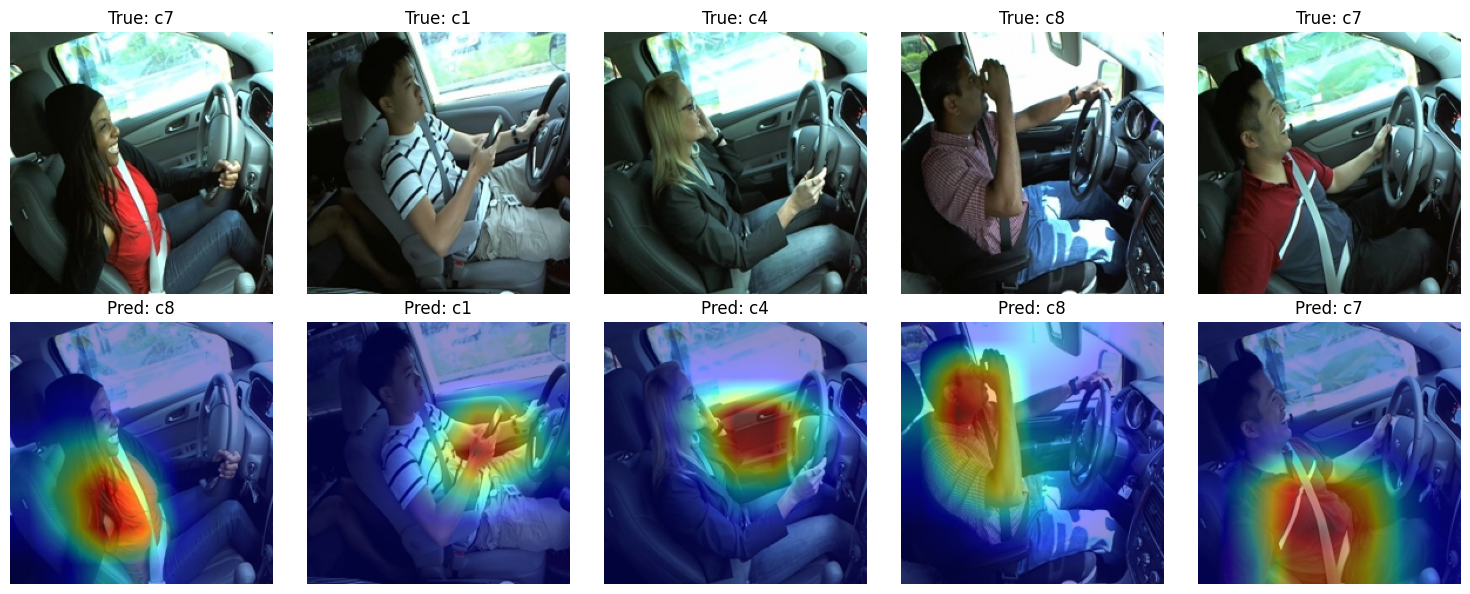

Đã lưu Grad-CAM grid: /kaggle/working/statefarm_effb0_project/plots/effb0_pretrained_finetune_gradcam_grid.png


In [28]:
PLOT_DIR = OUTPUT_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

if bool(globals().get("ENABLE_GRAD_CAM", True)):

    gradcam_exp_name = "effb0_pretrained_finetune"
    gradcam_rows = summary_df[summary_df["experiment"].astype(str) == gradcam_exp_name]
    if len(gradcam_rows) > 0:
        gradcam_checkpoint = gradcam_rows.iloc[0]["best_checkpoint"]
        gradcam_title_name = gradcam_exp_name
    else:
        gradcam_checkpoint = summary_df.iloc[0]["best_checkpoint"]
        gradcam_title_name = summary_df.iloc[0]["experiment"]

    gradcam_model = build_efficientnet_b0(num_classes=NUM_CLASSES, dropout=DROPOUT, pretrained=False).to(DEVICE)
    gradcam_model.load_state_dict(torch.load(gradcam_checkpoint, map_location=DEVICE))
    gradcam_model.eval()

    target_layer = gradcam_model.features[-1]
    cam_explainer = GradCAM(gradcam_model, target_layer)

    sample_rows = val_df.sample(min(5, len(val_df)), random_state=SEED).reset_index(drop=True)

    fig = plt.figure(figsize=(15, 6))

    for i, row in sample_rows.iterrows():
        raw_img = Image.open(row["img_path"]).convert("RGB")
        input_tensor = val_tfms(raw_img).unsqueeze(0).to(DEVICE)
        heatmap, pred_idx = cam_explainer(input_tensor)

        plt.subplot(2, len(sample_rows), i + 1)
        plt.imshow(raw_img.resize((IMG_SIZE, IMG_SIZE)))
        plt.title(f"True: {row['classname']}")
        plt.axis("off")

        plt.subplot(2, len(sample_rows), len(sample_rows) + i + 1)
        plt.imshow(raw_img.resize((IMG_SIZE, IMG_SIZE)))
        plt.imshow(heatmap, alpha=0.45, cmap="jet")
        plt.title(f"Pred: {idx_to_class[pred_idx]}")
        plt.axis("off")

    plt.tight_layout()

    gradcam_path = PLOT_DIR / f"{gradcam_title_name}_gradcam_grid.png"
    plt.savefig(gradcam_path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Đã lưu Grad-CAM grid:", gradcam_path)

    cam_explainer.close()
    clean_memory(label="sau Grad-CAM", verbose=False, kill_workers=False)

elif not bool(globals().get("ENABLE_GRAD_CAM", True)):
    print("ENABLE_GRAD_CAM=False nên bỏ qua Grad-CAM để tiết kiệm thời gian.")
else:
    print("Best model không phải EfficientNet-B0 nên bỏ qua Grad-CAM.")

if bool(False):
    clean_memory(label="sau Grad-CAM grid", verbose=False, kill_workers=False, deep=True)
